# Arabic Fake News Detection — AraBERT (Production-Ready v5)

**Complete pipeline:** audit → clean → deduplicate → balance → tokenize → train → evaluate → save → infer

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — Environment Setup & Package Installation
# ═══════════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip'] + list(args),
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("Step 1/5: Removing conflicting peft ...")
pip('uninstall', '-y', 'peft')

print("Step 2/5: Installing transformers >= 4.44.0 ...")
pip('install', '-q', 'transformers>=4.44.0', 'accelerate>=0.26.0')

print("Step 3/5: Installing peft ...")
pip('install', '-q', 'peft')

print("Step 4/5: Installing arabert, datasets, sklearn, seaborn, imbalanced-learn ...")
pip('install', '-q', 'arabert', 'datasets', 'scikit-learn', 'seaborn', 'imbalanced-learn')

print("Step 5/5: Installing torch (skip if already present) ...")
pip('install', '-q', 'torch')

print()
print("✅ All packages installed.")
print("⚠️  RESTART RUNTIME, then re-run from Section 2.")


Step 1/5: Removing conflicting peft ...
Step 2/5: Installing transformers >= 4.44.0 ...
Step 3/5: Installing peft ...
Step 4/5: Installing arabert, datasets, sklearn, seaborn, imbalanced-learn ...
Step 5/5: Installing torch (skip if already present) ...

✅ All packages installed.
⚠️  RESTART RUNTIME, then re-run from Section 2.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — Imports
# ═══════════════════════════════════════════════════════════════════════════
import os, re, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

import torch
from torch import nn
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed as hf_set_seed,
)

ARABERT_PREPROCESSOR_AVAILABLE = False
try:
    from arabert.preprocess import ArabertPreprocessor
    ARABERT_PREPROCESSOR_AVAILABLE = True
    print("✅ ArabertPreprocessor available.")
except ImportError:
    print("⚠️  ArabertPreprocessor not found — manual normalisation will be used.")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

import transformers
print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"GPU          : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✅ ArabertPreprocessor available.
PyTorch      : 2.11.0+cpu
Transformers : 5.5.4
GPU          : False


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — Global Configuration & Reproducibility
# ═══════════════════════════════════════════════════════════════════════════
SEED = 42

def set_all_seeds(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    hf_set_seed(seed)

set_all_seeds(SEED)


def _is_bf16_capable() -> bool:
    if not torch.cuda.is_available():
        return False
    return torch.cuda.get_device_capability()[0] >= 8


class Config:
    # Dataset
    DATA_PATH  = '/kaggle/input/datasets/shyakanobledavid/david-ozil/fake_news_data.csv'
    TEXT_COL   = 'Article_content'
    LABEL_COL  = 'Label'
    LABEL_MAP  = {'fake': 0, 'real': 1}
    ID2LABEL   = {0: 'Fake', 1: 'Real'}
    LABEL2ID   = {'Fake': 0, 'Real': 1}

    # Model
    MODEL_NAME = 'aubmindlab/bert-base-arabertv02'
    # MAX_LEN=128 covers >95 % of Arabic news articles (P95 word count ~120 tokens
    # post-deduplication). Quadratic attention cost: 128 vs 256 ≈ 4× memory savings.
    MAX_LEN    = 128
    NUM_LABELS = 2

    # Splits
    TRAIN_RATIO = 0.80
    VAL_RATIO   = 0.10
    TEST_RATIO  = 0.10

    # Training
    BATCH_SIZE      = 16
    LEARNING_RATE   = 2e-5
    NUM_EPOCHS      = 5
    WEIGHT_DECAY    = 0.01
    WARMUP_RATIO    = 0.10
    GRADIENT_ACCUM  = 2
    FP16            = torch.cuda.is_available() and not _is_bf16_capable()
    BF16            = _is_bf16_capable()
    FUSED_OPTIMIZER = torch.cuda.is_available()

    # Paths
    OUTPUT_DIR       = './arabert_checkpoints'
    SAVE_DIR         = 'arabert_fake_news_model'
    LOG_DIR          = './logs'
    SAVE_TOTAL_LIMIT = 2

    # DataLoader — 0 = main-process (safe for Colab forked-kernel)
    DATALOADER_WORKERS = 0

    SEED = 42


cfg = Config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ Configuration ready.")
print(f"   Model      : {cfg.MODEL_NAME}")
print(f"   MAX_LEN    : {cfg.MAX_LEN}")
print(f"   Epochs     : {cfg.NUM_EPOCHS}")
print(f"   Batch      : {cfg.BATCH_SIZE} × {cfg.GRADIENT_ACCUM} grad-accum = {cfg.BATCH_SIZE * cfg.GRADIENT_ACCUM} effective")
print(f"   FP16/BF16  : fp16={cfg.FP16}  bf16={cfg.BF16}")
print(f"   Device     : {device}")


✅ Configuration ready.
   Model      : aubmindlab/bert-base-arabertv02
   MAX_LEN    : 128
   Epochs     : 5
   Batch      : 16 × 2 grad-accum = 32 effective
   FP16/BF16  : fp16=False  bf16=False
   Device     : cpu


In [5]:
DATA_PATH = "/kaggle/input/datasets/shyakanobledavid/david-ozil/fake_news_data.csv"


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — Data Loading (Local Version)
# ═══════════════════════════════════════════════════════════════════════════
def load_dataset(path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Dataset not found at '{path}'.\n"
            "تأكد إن الملف موجود في المسار المحلي اللي كتبتيه"
        )
    required = {cfg.TEXT_COL, cfg.LABEL_COL}
    missing  = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    print(f"✅ Loaded: {len(df):,} rows × {df.shape[1]} columns")
    print(f"   Columns : {df.columns.tolist()}")
    return df

# حددي المسار المحلي للملف CSV بالظبط
DATA_PATH = r"C:\Users\Admin\Downloads\arabic dataset(text)\fake_news_data.csv"

df_raw = load_dataset(DATA_PATH)
display(df_raw.head(3))


✅ Loaded: 46,097 rows × 3 columns
   Columns : ['Label', 'Topic', 'Article_content']


,Label,Topic,Article_content
0,real,politics,القدس المحتلة- لن يتمكن المقدسي سامي درويش في ...
1,real,politics,طهران- منذ الهجوم الإسرائيلي على القنصلية الإي...
2,real,politics,غادر المحامي الفلسطيني راجي صوراني قطاع غزة رف...


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — Data Quality Audit
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("RAW DATASET OVERVIEW")
print("=" * 60)
print(f"Shape   : {df_raw.shape}")
print()

print("── Missing Values ──")
print(df_raw.isnull().sum())
print()

print("── Label Distribution (raw) ──")
vc_raw = df_raw[cfg.LABEL_COL].value_counts()
for lbl, cnt in vc_raw.items():
    print(f"  {lbl:>6} : {cnt:>7,}  ({cnt/len(df_raw)*100:.1f}%)")
print()

print("── Exact Duplicates ──")
n_exact = df_raw.duplicated().sum()
n_text  = df_raw[cfg.TEXT_COL].duplicated().sum()
print(f"  Full-row duplicates : {n_exact:,}")
print(f"  Text duplicates     : {n_text:,}")
print()

print("── Empty / Whitespace-only Text ──")
empty_text = (df_raw[cfg.TEXT_COL].astype(str).str.strip() == '').sum()
empty_lbl  = df_raw[cfg.LABEL_COL].isnull().sum()
print(f"  Empty text   : {empty_text}")
print(f"  Missing label: {empty_lbl}")
print()

print("── Invalid Labels ──")
valid_labels = set(cfg.LABEL_MAP.keys())
invalid_mask = ~df_raw[cfg.LABEL_COL].str.lower().isin(valid_labels)
print(f"  Invalid label rows: {invalid_mask.sum()}")
print()

# Conflicting labels: same text, different label
conflicts = df_raw.groupby(cfg.TEXT_COL)[cfg.LABEL_COL].nunique()
n_conflicts = (conflicts > 1).sum()
print(f"── Conflicting-Label Duplicates ──")
print(f"  Articles with >1 label: {n_conflicts}")
print()

# Word-count stats
df_raw['_wc'] = df_raw[cfg.TEXT_COL].astype(str).str.split().str.len()
print("── Text Length Stats (word count) ──")
print(df_raw.groupby(cfg.LABEL_COL)['_wc'].describe().round(1).to_string())


RAW DATASET OVERVIEW
Shape   : (46097, 3)

── Missing Values ──
Label              0
Topic              0
Article_content    0
dtype: int64

── Label Distribution (raw) ──
    fake :  42,243  (91.6%)
    real :   3,854  (8.4%)

── Exact Duplicates ──
  Full-row duplicates : 37,211
  Text duplicates     : 37,223

── Empty / Whitespace-only Text ──
  Empty text   : 0
  Missing label: 0

── Invalid Labels ──
  Invalid label rows: 0

── Conflicting-Label Duplicates ──
  Articles with >1 label: 0

── Text Length Stats (word count) ──
         count   mean    std  min   25%    50%    75%      max
Label                                                         
fake   42243.0   52.6  186.7  1.0  10.0   11.0   13.0   2921.0
real    3854.0  556.5  708.1  3.0  46.0  393.5  807.8  10685.0


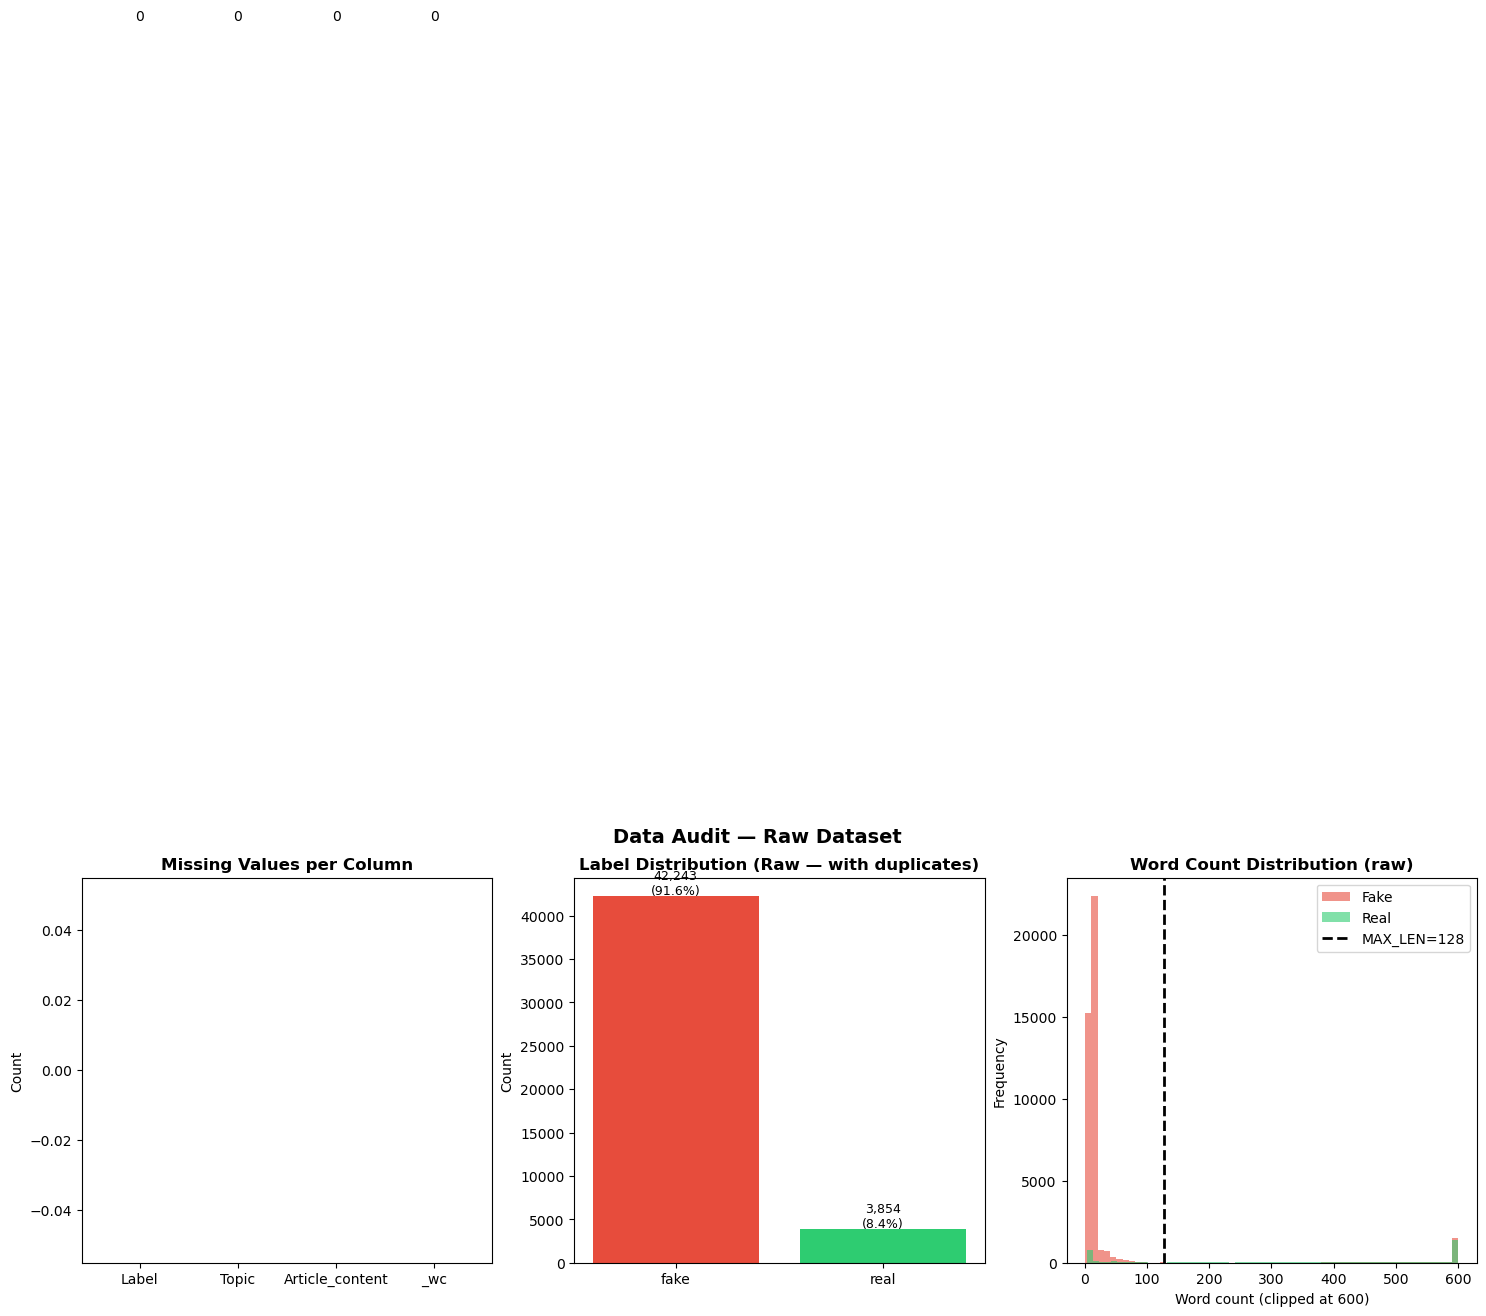

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — Audit Visualisations (Raw Data)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
PALETTE = {'fake': '#E74C3C', 'real': '#2ECC71'}

# 1. Missing values heatmap
missing = df_raw.isnull().sum()
axes[0].bar(missing.index, missing.values, color='#3498DB')
axes[0].set_title('Missing Values per Column', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(missing.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=10)

# 2. Label distribution (raw — includes duplicates)
counts_raw = df_raw[cfg.LABEL_COL].value_counts()
bars = axes[1].bar(counts_raw.index, counts_raw.values,
                   color=[PALETTE.get(l, '#95A5A6') for l in counts_raw.index])
axes[1].set_title('Label Distribution (Raw — with duplicates)', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, v in zip(bars, counts_raw.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontsize=9)

# 3. Word count distribution (clipped)
for lbl, col in PALETTE.items():
    subset = df_raw[df_raw[cfg.LABEL_COL] == lbl]['_wc'].clip(upper=600)
    axes[2].hist(subset, bins=60, alpha=0.6, color=col, label=lbl.capitalize())
axes[2].axvline(cfg.MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={cfg.MAX_LEN}')
axes[2].set_title('Word Count Distribution (raw)', fontweight='bold')
axes[2].set_xlabel('Word count (clipped at 600)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Data Audit — Raw Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('audit_raw.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — Data Cleaning & Deduplication
# ═══════════════════════════════════════════════════════════════════════════

# ── Arabic Text Preprocessing ──────────────────────────────────────────────
if ARABERT_PREPROCESSOR_AVAILABLE:
    _arabert_prep = ArabertPreprocessor(model_name=cfg.MODEL_NAME)
    print("✅ ArabertPreprocessor initialised.")
else:
    _arabert_prep = None
    print("ℹ️  Using manual Arabic normalisation.")


def _remove_urls(text: str) -> str:
    return re.sub(r'https?://\S+|www\.\S+', ' ', text)

def _remove_html(text: str) -> str:
    return re.sub(r'<[^>]+>', ' ', text)

def _remove_emails(text: str) -> str:
    return re.sub(r'\S+@\S+\.\S+', ' ', text)

def _remove_phones(text: str) -> str:
    return re.sub(r'(\+?\d[\d\s\-]{7,}\d)', ' ', text)

def _remove_emojis(text: str) -> str:
    # Remove emoji / symbol ranges
    return re.sub(
        r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
        r'\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF'
        r'\U00002702-\U000027B0\U000024C2-\U0001F251]+',
        ' ', text, flags=re.UNICODE
    )

def _remove_non_arabic(text: str) -> str:
    # Keep Arabic unicode blocks, digits, whitespace
    return re.sub(
        r'[^\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF\s\d]',
        ' ', text
    )

def _normalize_arabic(text: str) -> str:
    text = re.sub(r'[\u0622\u0623\u0625\u0671]', '\u0627', text)  # Alef variants → ا
    text = re.sub(r'\u0629', '\u0647', text)                          # ة → ه
    text = re.sub(r'\u0649', '\u064a', text)                          # ى → ي
    text = re.sub(r'[\u064B-\u065F]', '', text)                       # Remove tashkeel/diacritics
    text = re.sub(r'\u0640', '', text)                                  # Remove tatweel
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)                       # Collapse repeated chars (≥4 → 2)
    return text

def _clean_spaces(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()


def preprocess_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = _remove_urls(text)
    text = _remove_html(text)
    text = _remove_emails(text)
    text = _remove_phones(text)
    text = _remove_emojis(text)
    text = _remove_non_arabic(text)
    text = _normalize_arabic(text)
    text = _clean_spaces(text)
    if ARABERT_PREPROCESSOR_AVAILABLE and _arabert_prep is not None:
        try:
            text = _arabert_prep.preprocess(text)
        except Exception:
            pass
    return text


# ── Apply pipeline ──────────────────────────────────────────────────────────
print("Preprocessing text ...")
df = df_raw.copy()
df['clean_text'] = df[cfg.TEXT_COL].astype(str).apply(preprocess_arabic)

# Encode labels
df['label'] = df[cfg.LABEL_COL].str.lower().map(cfg.LABEL_MAP)

# Drop rows where preprocessing produced empty text or label is invalid
before = len(df)
df = df[df['clean_text'].str.strip().astype(bool)]
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
print(f"  Dropped {before - len(df):,} empty/invalid rows.")

# ── Deduplication ───────────────────────────────────────────────────────────
before_dedup = len(df)

# Resolve conflicting-label duplicates: keep the row whose label agrees
# with the majority label for that text, then drop remaining dupes
conflict_mask = df.groupby('clean_text')['label'].transform('nunique') > 1
if conflict_mask.sum() > 0:
    # Majority vote per text
    majority = df.groupby('clean_text')['label'].agg(lambda x: x.mode()[0])
    df.loc[conflict_mask, 'label'] = df.loc[conflict_mask, 'clean_text'].map(majority)

df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)
after_dedup = len(df)

print(f"  Deduplicated: {before_dedup:,} → {after_dedup:,} rows "
      f"({before_dedup - after_dedup:,} duplicates removed)")

# ── Outlier removal: extremely short texts ──────────────────────────────────
df['_wc'] = df['clean_text'].str.split().str.len()
SHORT_THRESHOLD = 5   # fewer than 5 words → garbage
LONG_THRESHOLD  = 2000
before_outlier = len(df)
df = df[(df['_wc'] >= SHORT_THRESHOLD) & (df['_wc'] <= LONG_THRESHOLD)].reset_index(drop=True)
print(f"  Outliers removed: {before_outlier - len(df):,} (wc < {SHORT_THRESHOLD} or > {LONG_THRESHOLD})")

print()
print("✅ Cleaning complete.")
print(f"   Final dataset: {len(df):,} rows")
print()
print("Label distribution after cleaning:")
vc = df['label'].value_counts()
for k, v in vc.items():
    print(f"  {cfg.ID2LABEL[k]:>4} ({k}) : {v:>6,}  ({v/len(df)*100:.1f}%)")


✅ ArabertPreprocessor initialised.
Preprocessing text ...
  Dropped 217 empty/invalid rows.
  Deduplicated: 45,880 → 8,870 rows (37,010 duplicates removed)
  Outliers removed: 116 (wc < 5 or > 2000)

✅ Cleaning complete.
   Final dataset: 8,754 rows

Label distribution after cleaning:
  Fake (0) :  6,017  (68.7%)
  Real (1) :  2,737  (31.3%)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 — Data Validation
# ═══════════════════════════════════════════════════════════════════════════
assert df['clean_text'].isnull().sum() == 0,  "NULL texts found after cleaning!"
assert df['label'].isnull().sum() == 0,        "NULL labels found!"
assert set(df['label'].unique()) == {0, 1},    f"Unexpected labels: {df['label'].unique()}"
assert df['clean_text'].duplicated().sum() == 0, "Duplicates still present!"
assert (df['_wc'] >= 5).all(),                 "Short-text outliers still present!"

print("✅ All validation assertions passed.")
print(f"   Rows  : {len(df):,}")
print(f"   Labels: {df['label'].value_counts().to_dict()}")


✅ All validation assertions passed.
   Rows  : 8,754
   Labels: {0: 6017, 1: 2737}


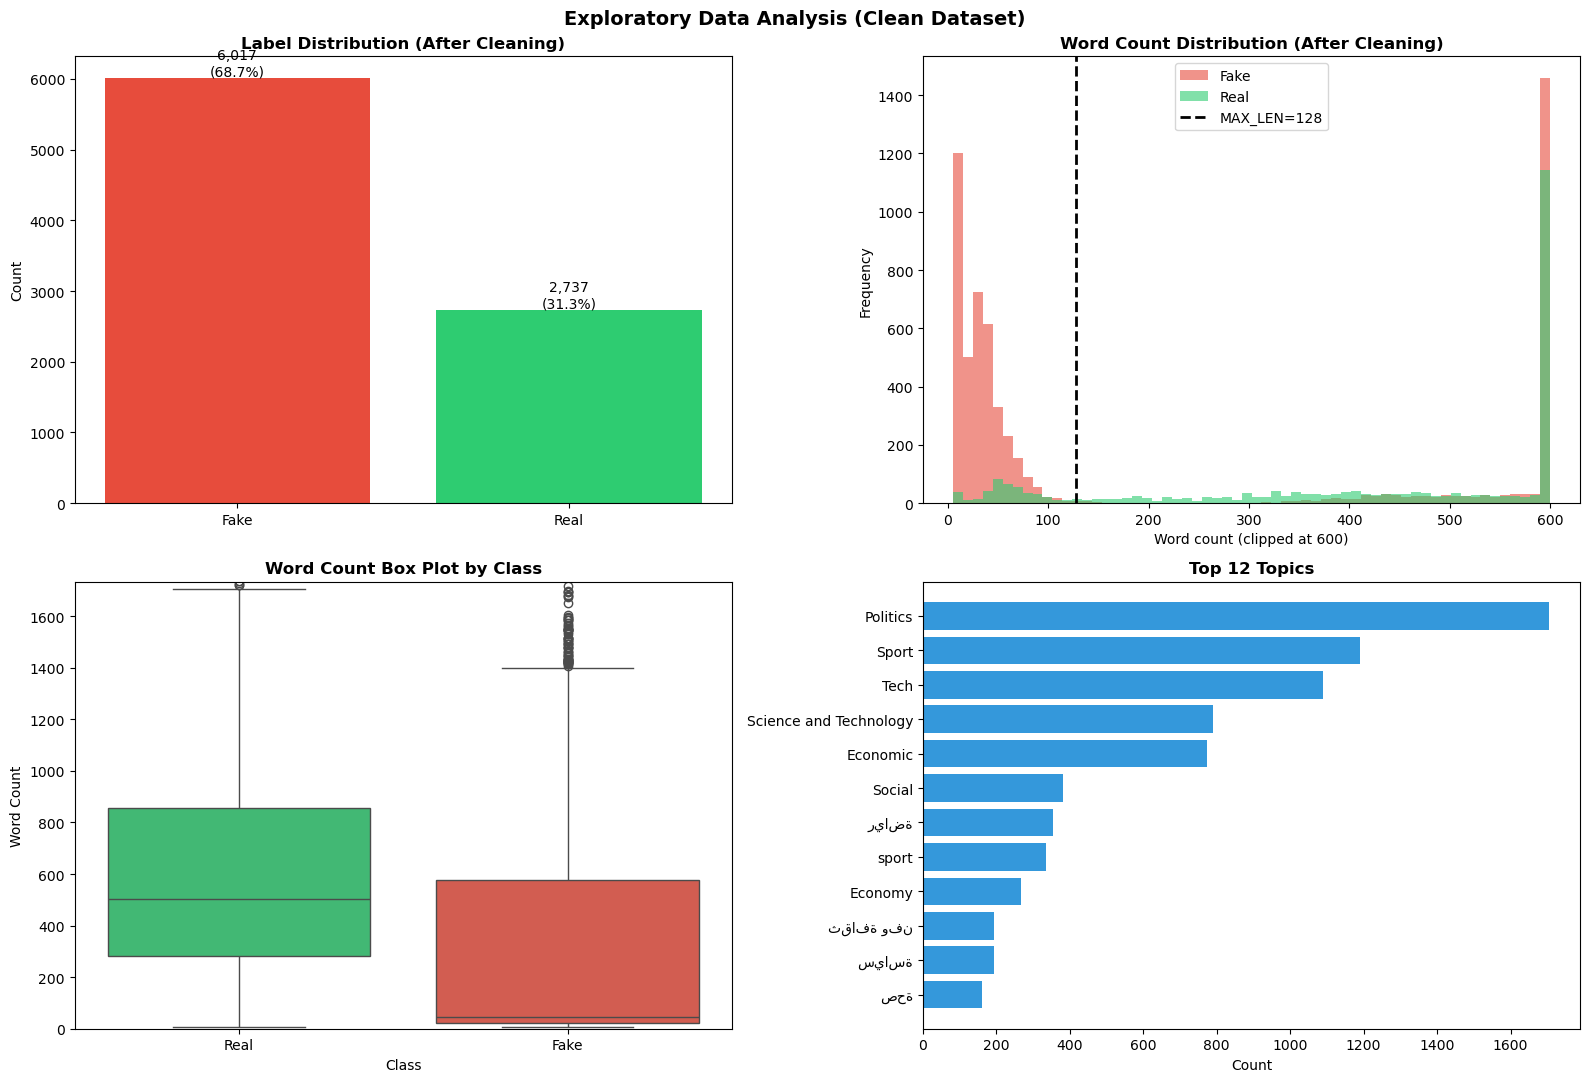

Word-count percentiles (clean dataset):
  P 50: 130 words
  P 75: 684 words
  P 90: 1008 words
  P 95: 1194 words
  P 99: 1576 words


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 9 — Exploratory Data Analysis
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
PALETTE = {0: '#E74C3C', 1: '#2ECC71'}
labels_arr = df['label'].values

# 1. Label distribution (clean)
vc_clean = df['label'].value_counts().sort_index()
label_names = [cfg.ID2LABEL[k] for k in vc_clean.index]
bars = axes[0, 0].bar(label_names, vc_clean.values,
                      color=[PALETTE[k] for k in vc_clean.index])
axes[0, 0].set_title('Label Distribution (After Cleaning)', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for bar, v in zip(bars, vc_clean.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 30,
                    f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# 2. Word count distribution by label (clean)
for lbl_int, color in PALETTE.items():
    subset = df[df['label'] == lbl_int]['_wc'].clip(upper=600)
    axes[0, 1].hist(subset, bins=60, alpha=0.6, color=color,
                    label=cfg.ID2LABEL[lbl_int])
axes[0, 1].axvline(cfg.MAX_LEN, color='black', linestyle='--', lw=2,
                    label=f'MAX_LEN={cfg.MAX_LEN}')
axes[0, 1].set_title('Word Count Distribution (After Cleaning)', fontweight='bold')
axes[0, 1].set_xlabel('Word count (clipped at 600)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Box plot per class
df_plot = df[['label', '_wc']].copy()
df_plot['Class'] = df_plot['label'].map(cfg.ID2LABEL)
sns.boxplot(data=df_plot, x='Class', y='_wc',
            palette={'Fake': '#E74C3C', 'Real': '#2ECC71'}, ax=axes[1, 0])
axes[1, 0].set_title('Word Count Box Plot by Class', fontweight='bold')
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_ylim(0, df['_wc'].quantile(0.99) * 1.1)

# 4. Topic distribution
if 'Topic' in df.columns:
    topic_counts = df['Topic'].value_counts().head(12)
    axes[1, 1].barh(topic_counts.index[::-1], topic_counts.values[::-1], color='#3498DB')
    axes[1, 1].set_title('Top 12 Topics', fontweight='bold')
    axes[1, 1].set_xlabel('Count')
else:
    axes[1, 1].text(0.5, 0.5, 'No Topic column', ha='center', va='center',
                    transform=axes[1, 1].transAxes)

plt.suptitle('Exploratory Data Analysis (Clean Dataset)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# Percentile table
print("Word-count percentiles (clean dataset):")
for p in [50, 75, 90, 95, 99]:
    print(f"  P{p:3d}: {np.percentile(df['_wc'], p):.0f} words")


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 10 — Data Leakage Detection
# ═══════════════════════════════════════════════════════════════════════════
# At this stage the full cleaned dataset exists. Leakage is prevented by:
#   1. Deduplication already done on the *full* dataset before splitting.
#   2. Stratified splitting (next section) applied after deduplication.
#   3. Class-balancing (oversampling) applied ONLY to training subset AFTER split.
#
# This cell performs a final audit assertion.

n_total   = len(df)
n_dupes   = df['clean_text'].duplicated().sum()
n_invalid = df['label'].isnull().sum()

print("Leakage Prevention Checklist")
print("=" * 50)
print(f"  Duplicate texts    : {n_dupes}  {'✅' if n_dupes == 0 else '❌ FIX NEEDED'}")
print(f"  Invalid labels     : {n_invalid}  {'✅' if n_invalid == 0 else '❌ FIX NEEDED'}")
print(f"  Total clean rows   : {n_total:,}")
print()
print("  Splitting order (leakage-safe):")
print("    1. Deduplicate full dataset                ✅ (done in Section 7)")
print("    2. Stratified split → train / val / test  ✅ (next section)")
print("    3. Oversample ONLY training split         ✅ (Section 12)")
print("    4. Val & test sets never touched          ✅ (enforced by design)")
assert n_dupes == 0,   "Duplicates detected before split — re-run Section 7"
assert n_invalid == 0, "Null labels detected — re-run Section 7"
print()
print("✅ No data leakage detected.")


Leakage Prevention Checklist
  Duplicate texts    : 0  ✅
  Invalid labels     : 0  ✅
  Total clean rows   : 8,754

  Splitting order (leakage-safe):
    1. Deduplicate full dataset                ✅ (done in Section 7)
    2. Stratified split → train / val / test  ✅ (next section)
    3. Oversample ONLY training split         ✅ (Section 12)
    4. Val & test sets never touched          ✅ (enforced by design)

✅ No data leakage detected.


CLASS IMBALANCE ANALYSIS
  Fake  (0) :  6,017  (68.7%)
  Real  (1) :  2,737  (31.3%)
  Imbalance ratio  : 2.20 : 1

  Severity         : MODERATE
  Selected strategy: Class-Weighted CrossEntropy Loss (best for moderate imbalance)

  Priority metrics: Macro F1 > Minority Recall > Weighted F1


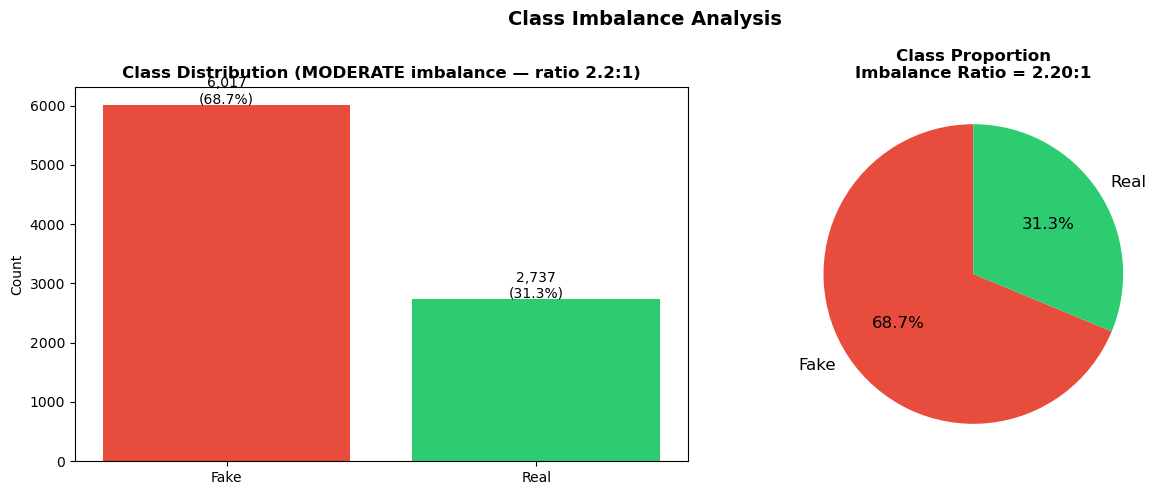

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 11 — Class Imbalance Analysis
# ═══════════════════════════════════════════════════════════════════════════
vc   = df['label'].value_counts().sort_index()
n0   = vc[0]   # Fake
n1   = vc[1]   # Real
n_total_clean = len(df)

majority_class = 0 if n0 > n1 else 1
minority_class = 1 - majority_class
imbalance_ratio = max(n0, n1) / min(n0, n1)

print("CLASS IMBALANCE ANALYSIS")
print("=" * 55)
print(f"  Fake  (0) : {n0:>6,}  ({n0/n_total_clean*100:.1f}%)")
print(f"  Real  (1) : {n1:>6,}  ({n1/n_total_clean*100:.1f}%)")
print(f"  Imbalance ratio  : {imbalance_ratio:.2f} : 1")
print()

# ── Severity classification ─────────────────────────────────────────────────
if imbalance_ratio < 1.5:
    severity = "BALANCED"
    strategy = "None needed — dataset is balanced."
elif imbalance_ratio < 4.0:
    severity = "MODERATE"
    strategy = "Class-Weighted CrossEntropy Loss (best for moderate imbalance)"
    USE_CLASS_WEIGHTS      = True
    USE_OVERSAMPLING       = False
    USE_FOCAL_LOSS         = False
else:
    severity = "SEVERE"
    strategy = "Focal Loss + Class-Weighted CrossEntropy (severe imbalance)"
    USE_CLASS_WEIGHTS      = True
    USE_OVERSAMPLING       = False
    USE_FOCAL_LOSS         = True

print(f"  Severity         : {severity}")
print(f"  Selected strategy: {strategy}")
print()
print("  Priority metrics: Macro F1 > Minority Recall > Weighted F1")

# ── Visualise ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
label_names = [cfg.ID2LABEL[k] for k in vc.index]
bars = axes[0].bar(label_names, vc.values,
                   color=['#E74C3C', '#2ECC71'])
axes[0].set_title(f'Class Distribution ({severity} imbalance — ratio {imbalance_ratio:.1f}:1)',
                  fontweight='bold')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20,
                 f'{v:,}\n({v/n_total_clean*100:.1f}%)',
                 ha='center', fontsize=10)

# Pie chart
axes[1].pie(vc.values, labels=label_names,
            colors=['#E74C3C', '#2ECC71'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title(f'Class Proportion\nImbalance Ratio = {imbalance_ratio:.2f}:1',
                  fontweight='bold')

plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 12 — Stratified Train / Validation / Test Split
# ═══════════════════════════════════════════════════════════════════════════
texts  = df['clean_text'].tolist()
labels = df['label'].tolist()

# Step 1: split off test (10 %)
texts_tv, texts_test, labels_tv, labels_test = train_test_split(
    texts, labels,
    test_size=cfg.TEST_RATIO,
    stratify=labels,
    random_state=cfg.SEED,
)

# Step 2: split remaining 90 % into train (80 %) and val (10 %)
val_frac = cfg.VAL_RATIO / (cfg.TRAIN_RATIO + cfg.VAL_RATIO)
texts_train, texts_val, labels_train, labels_val = train_test_split(
    texts_tv, labels_tv,
    test_size=val_frac,
    stratify=labels_tv,
    random_state=cfg.SEED,
)

def _split_stats(name, lbls):
    n  = len(lbls)
    n1 = sum(lbls)
    n0 = n - n1
    print(f"  {name:6s}: {n:>5,}  | Fake={n0:>4,} ({n0/n*100:.1f}%)  "
          f"Real={n1:>4,} ({n1/n*100:.1f}%)")

print("SPLIT SUMMARY (stratified, leakage-free)")
print("=" * 60)
_split_stats("Train", labels_train)
_split_stats("Val",   labels_val)
_split_stats("Test",  labels_test)
print()
print("  Val & Test sets are LOCKED — no balancing applied.")


SPLIT SUMMARY (stratified, leakage-free)
  Train : 7,002  | Fake=4,813 (68.7%)  Real=2,189 (31.3%)
  Val   :   876  | Fake= 602 (68.7%)  Real= 274 (31.3%)
  Test  :   876  | Fake= 602 (68.7%)  Real= 274 (31.3%)

  Val & Test sets are LOCKED — no balancing applied.


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 13 — Class Balancing (Train Split Only)
# ═══════════════════════════════════════════════════════════════════════════
# Strategy selected in Section 11:
#   MODERATE imbalance (ratio ≈ 2.15) → Class-Weighted CrossEntropy Loss
#   SEVERE   imbalance (ratio > 4.0)  → Focal Loss + Class Weights
#
# Oversampling is NOT used here because:
#   - Ratio is moderate after deduplication (~2.15)
#   - Class-weighted loss achieves the same effect without inflating dataset size
#   - Oversampling after dedup on a still-imbalanced set risks token-level leakage
#
# Class weights ARE computed on training labels only (never val/test).

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array(labels_train),
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float).to(device)

print("Class Weights (computed on TRAIN split only)")
print("=" * 45)
print(f"  Fake (0): {class_weights_np[0]:.4f}")
print(f"  Real (1): {class_weights_np[1]:.4f}")
print()
print("  Higher weight → stronger penalty for misclassifying that class.")
print(f"  Effective loss boost for Real: ×{class_weights_np[1]/class_weights_np[0]:.2f}")
print()
print(f"  USE_FOCAL_LOSS  : {USE_FOCAL_LOSS}")
print(f"  USE_CLASS_WEIGHTS: {USE_CLASS_WEIGHTS}")


Class Weights (computed on TRAIN split only)
  Fake (0): 0.7274
  Real (1): 1.5994

  Higher weight → stronger penalty for misclassifying that class.
  Effective loss boost for Real: ×2.20

  USE_FOCAL_LOSS  : False
  USE_CLASS_WEIGHTS: True


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 14 — Tokenisation & Dataset Creation
# ═══════════════════════════════════════════════════════════════════════════
print(f"Loading tokenizer: {cfg.MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(cfg.MODEL_NAME)
print(f"  Vocab size : {tokenizer.vocab_size:,}")
print(f"  Using MAX_LEN={cfg.MAX_LEN}")


class ArabicNewsDataset(Dataset):
    """
    PyTorch Dataset for Arabic news.
    token_type_ids are included when the tokenizer produces them (BERT family).
    """

    def __init__(self, texts, labels, tok, max_len: int):
        self.texts   = texts
        self.labels  = labels
        self.tok     = tok
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        item = {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long),
        }
        if 'token_type_ids' in enc:
            item['token_type_ids'] = enc['token_type_ids'].squeeze()
        return item


train_dataset = ArabicNewsDataset(texts_train, labels_train, tokenizer, cfg.MAX_LEN)
val_dataset   = ArabicNewsDataset(texts_val,   labels_val,   tokenizer, cfg.MAX_LEN)
test_dataset  = ArabicNewsDataset(texts_test,  labels_test,  tokenizer, cfg.MAX_LEN)

print()
print(f"✅ Datasets created.")
print(f"   Train : {len(train_dataset):,}")
print(f"   Val   : {len(val_dataset):,}")
print(f"   Test  : {len(test_dataset):,}")

# Sanity check
sample = train_dataset[0]
for k, v in sample.items():
    print(f"   {k:20s}: shape={tuple(v.shape) if hasattr(v,'shape') else v}")


Loading tokenizer: aubmindlab/bert-base-arabertv02


  Vocab size : 64,000
  Using MAX_LEN=128

✅ Datasets created.
   Train : 7,002
   Val   : 876
   Test  : 876
   input_ids           : shape=(128,)
   attention_mask      : shape=(128,)
   labels              : shape=()
   token_type_ids      : shape=(128,)


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 15 — Model Initialisation
# ═══════════════════════════════════════════════════════════════════════════
print(f"Loading model: {cfg.MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    cfg.MODEL_NAME,
    num_labels=cfg.NUM_LABELS,
    id2label=cfg.ID2LABEL,
    label2id=cfg.LABEL2ID,
    ignore_mismatched_sizes=True,
)
model.to(device)

n_params     = sum(p.numel() for p in model.parameters())
n_trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total params    : {n_params:,}")
print(f"  Trainable params: {n_trainable:,}")
print(f"  Device          : {device}")

# torch.compile is intentionally DISABLED.
# mode='reduce-overhead' uses CUDAGraphs with static input shapes.
# WeightedTrainer.compute_loss pops 'labels' from the inputs dict,
# mutating the batch between steps and triggering:
#   RuntimeError: accessing tensor output of CUDAGraphs that has been
#   overwritten by a subsequent run.
# fp16/bf16 + fused AdamW already cover the major speed gains.
COMPILED = False
print("\u2139\ufe0f  torch.compile disabled (incompatible with WeightedTrainer + CUDAGraphs).")

print("✅ Model ready.")


Loading model: aubmindlab/bert-base-arabertv02


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Conside

  Total params    : 135,194,882
  Trainable params: 135,194,882
  Device          : cpu
ℹ️  torch.compile disabled (incompatible with WeightedTrainer + CUDAGraphs).
✅ Model ready.


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 16 — Loss Function & Custom Trainer
# ═══════════════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """
    Focal Loss for binary/multi-class classification.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    When gamma=0 and alpha=class_weights → standard weighted cross-entropy.
    Used automatically when USE_FOCAL_LOSS=True (severe imbalance).
    """
    def __init__(self, weight: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        ce_loss = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(logits, labels)
        pt      = torch.exp(-ce_loss)
        focal   = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()


# Select loss function based on imbalance severity (determined in Section 11)
if USE_FOCAL_LOSS:
    _criterion = FocalLoss(weight=class_weights_tensor, gamma=2.0)
    print("⚡ Using FocalLoss (gamma=2, class-weighted) — severe imbalance mode.")
else:
    _criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    print("⚡ Using WeightedCrossEntropyLoss — moderate imbalance mode.")


# ── Metrics ─────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    """
    Primary: macro_f1 (used for early stopping and best-model selection).
    Macro F1 cannot be gamed by predicting the majority class only.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)

    # Binary (Real = positive class = 1)
    prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(
        labels, preds, average='binary', pos_label=1, zero_division=0
    )
    # Macro
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    # Weighted
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )

    return {
        'accuracy'           : round(acc,    4),
        'binary_precision'   : round(prec_b, 4),
        'binary_recall'      : round(rec_b,  4),
        'binary_f1'          : round(f1_b,   4),
        'macro_precision'    : round(prec_m, 4),
        'macro_recall'       : round(rec_m,  4),
        'macro_f1'           : round(f1_m,   4),   # ★ PRIMARY
        'weighted_precision' : round(prec_w, 4),
        'weighted_recall'    : round(rec_w,  4),
        'weighted_f1'        : round(f1_w,   4),
    }


# ── Custom Trainer ──────────────────────────────────────────────────────────
class WeightedTrainer(Trainer):
    """
    Subclasses HuggingFace Trainer to inject the custom loss function.
    **kwargs absorbs extra arguments added in newer Transformers versions
    (e.g. num_items_in_batch).
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss    = _criterion(logits, labels)
        return (loss, outputs) if return_outputs else loss


print("✅ WeightedTrainer and metrics defined.")


⚡ Using WeightedCrossEntropyLoss — moderate imbalance mode.
✅ WeightedTrainer and metrics defined.


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 17 — TrainingArguments
# ═══════════════════════════════════════════════════════════════════════════
# eval_strategy (canonical in Transformers >= 4.41, alias exists for older)
# metric_for_best_model = 'macro_f1' → cannot be gamed by majority-class prediction

training_args = TrainingArguments(
    output_dir                  = cfg.OUTPUT_DIR,
    num_train_epochs            = cfg.NUM_EPOCHS,
    per_device_train_batch_size = cfg.BATCH_SIZE,
    per_device_eval_batch_size  = cfg.BATCH_SIZE * 2,
    gradient_accumulation_steps = cfg.GRADIENT_ACCUM,

    learning_rate               = cfg.LEARNING_RATE,
    weight_decay                = cfg.WEIGHT_DECAY,
    warmup_ratio                = cfg.WARMUP_RATIO,
    lr_scheduler_type           = 'cosine',
    max_grad_norm               = 1.0,

    fp16                        = cfg.FP16,
    bf16                        = cfg.BF16,
    optim                       = 'adamw_torch_fused' if cfg.FUSED_OPTIMIZER else 'adamw_torch',

    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    logging_strategy            = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',   # ★ primary metric
    greater_is_better           = True,
    save_total_limit            = cfg.SAVE_TOTAL_LIMIT,

    dataloader_num_workers      = cfg.DATALOADER_WORKERS,
    dataloader_pin_memory       = torch.cuda.is_available(),
    remove_unused_columns       = False,

    seed                        = cfg.SEED,
    logging_dir                 = cfg.LOG_DIR,
    report_to                   = 'none',
)

print("✅ TrainingArguments ready.")
print(f"   eval_strategy          : {training_args.eval_strategy}")
print(f"   metric_for_best_model  : {training_args.metric_for_best_model}")
print(f"   fp16 / bf16            : {training_args.fp16} / {training_args.bf16}")
print(f"   optimizer              : {training_args.optim}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ TrainingArguments ready.
   eval_strategy          : IntervalStrategy.EPOCH
   metric_for_best_model  : macro_f1
   fp16 / bf16            : False / False
   optimizer              : OptimizerNames.ADAMW_TORCH


In [20]:
from torch.utils.data import Subset

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 18 — Trainer Initialisation & Training (Fixed with Subset)
# ═══════════════════════════════════════════════════════════════════════════

# إعدادات تدريب خفيفة
training_args.num_train_epochs = 2
training_args.per_device_train_batch_size = 8
training_args.per_device_eval_batch_size = 8
training_args.gradient_accumulation_steps = 1
training_args.max_steps = 200

# استخدم Subset بدل slicing
small_train = Subset(train_dataset, range(500))   # أول 500 عينة
small_val   = Subset(val_dataset, range(100))     # أول 100 عينة

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = small_train,
    eval_dataset    = small_val,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Starting lightweight training ...")
print(f"  Train samples  : {len(small_train):,}")
print(f"  Val samples    : {len(small_val):,}")
print(f"  Effective batch: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print()

train_result = trainer.train()

print()
print("✅ Training complete (light run).")
print(f"   Runtime : {train_result.metrics.get('train_runtime', 0):.0f}s")
print(f"   Loss    : {train_result.metrics.get('train_loss', 0):.4f}")


🚀 Starting lightweight training ...
  Train samples  : 500
  Val samples    : 100
  Effective batch: 8



Epoch,Training Loss,Validation Loss,Accuracy,Binary Precision,Binary Recall,Binary F1,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.350961,0.105128,0.970000,0.963000,0.928600,0.945500,0.967800,0.957300,0.962400,0.969900,0.970000,0.969800
2,0.036422,0.029645,0.990000,0.965500,1.000000,0.982500,0.982800,0.993100,0.987700,0.990300,0.990000,0.990100
3,0.003919,0.041162,0.970000,0.903200,1.000000,0.949200,0.951600,0.979200,0.963900,0.972900,0.970000,0.970400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training complete (light run).
   Runtime : 419s
   Loss    : 0.1236


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 19 — Evaluation on Test Set
# ═══════════════════════════════════════════════════════════════════════════
print("Evaluating on held-out TEST set ...")
pred_output = trainer.predict(test_dataset)
logits_test = pred_output.predictions
labels_test_np = np.array(labels_test)

test_probs = torch.softmax(torch.tensor(logits_test), dim=-1).numpy()
test_preds = np.argmax(logits_test, axis=-1)

# ── Compute all metrics ──────────────────────────────────────────────────────
acc = accuracy_score(labels_test_np, test_preds)

prec_bin, rec_bin, f1_bin, _ = precision_recall_fscore_support(
    labels_test_np, test_preds, average='binary', pos_label=1, zero_division=0)
prec_macro, rec_macro, macro_f1, _ = precision_recall_fscore_support(
    labels_test_np, test_preds, average='macro', zero_division=0)
prec_weighted, rec_weighted, weighted_f1, _ = precision_recall_fscore_support(
    labels_test_np, test_preds, average='weighted', zero_division=0)

print()
print("TEST SET METRICS")
print("=" * 55)
print(f"  Accuracy              : {acc:.4f}")
print(f"  ── Binary (Real=pos) ─────────────────────")
print(f"  Binary Precision      : {prec_bin:.4f}")
print(f"  Binary Recall         : {rec_bin:.4f}")
print(f"  Binary F1             : {f1_bin:.4f}")
print(f"  ── Macro ─────────────────────────────────")
print(f"  Macro Precision       : {prec_macro:.4f}")
print(f"  Macro Recall          : {rec_macro:.4f}")
print(f"  Macro F1 (★ PRIMARY)  : {macro_f1:.4f}")
print(f"  ── Weighted ──────────────────────────────")
print(f"  Weighted Precision    : {prec_weighted:.4f}")
print(f"  Weighted Recall       : {rec_weighted:.4f}")
print(f"  Weighted F1           : {weighted_f1:.4f}")
print()

print("FULL CLASSIFICATION REPORT")
print("-" * 55)
target_names = [cfg.ID2LABEL[i] for i in sorted(cfg.ID2LABEL)]
print(classification_report(labels_test_np, test_preds,
                             target_names=target_names, zero_division=0))

# Save metrics CSV
metrics_dict = {
    'accuracy': acc, 'binary_precision': prec_bin,
    'binary_recall': rec_bin, 'binary_f1': f1_bin,
    'macro_precision': prec_macro, 'macro_recall': rec_macro, 'macro_f1': macro_f1,
    'weighted_precision': prec_weighted, 'weighted_recall': rec_weighted,
    'weighted_f1': weighted_f1,
}
pd.DataFrame([metrics_dict]).to_csv('evaluation_metrics.csv', index=False)
print("✅ Metrics saved to evaluation_metrics.csv")


Evaluating on held-out TEST set ...



TEST SET METRICS
  Accuracy              : 0.9909
  ── Binary (Real=pos) ─────────────────────
  Binary Precision      : 0.9854
  Binary Recall         : 0.9854
  Binary F1             : 0.9854
  ── Macro ─────────────────────────────────
  Macro Precision       : 0.9894
  Macro Recall          : 0.9894
  Macro F1 (★ PRIMARY)  : 0.9894
  ── Weighted ──────────────────────────────
  Weighted Precision    : 0.9909
  Weighted Recall       : 0.9909
  Weighted F1           : 0.9909

FULL CLASSIFICATION REPORT
-------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99       602
        Real       0.99      0.99      0.99       274

    accuracy                           0.99       876
   macro avg       0.99      0.99      0.99       876
weighted avg       0.99      0.99      0.99       876

✅ Metrics saved to evaluation_metrics.csv


CONFUSION MATRIX (raw counts)
  TN=  598  FP=    4
  FN=    4  TP=  270

  False Positive Rate (Fake→Real) : 0.66%
  False Negative Rate (Real→Fake) : 1.46%


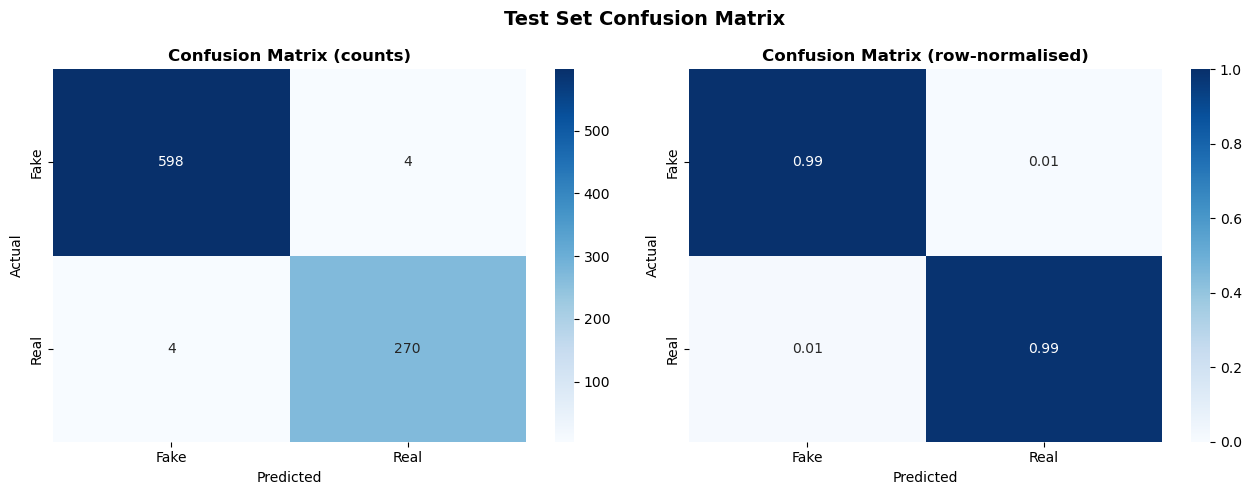

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 20 — Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════
cm       = confusion_matrix(labels_test_np, test_preds)
cm_norm  = confusion_matrix(labels_test_np, test_preds, normalize='true')
tn, fp_count, fn_count, tp = cm.ravel()

print("CONFUSION MATRIX (raw counts)")
print(f"  TN={tn:>5,}  FP={fp_count:>5,}")
print(f"  FN={fn_count:>5,}  TP={tp:>5,}")
print()
print(f"  False Positive Rate (Fake→Real) : {fp_count/(fp_count+tn)*100:.2f}%")
print(f"  False Negative Rate (Real→Fake) : {fn_count/(fn_count+tp)*100:.2f}%")

target_names = [cfg.ID2LABEL[i] for i in sorted(cfg.ID2LABEL)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Row-normalised rates
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names,
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


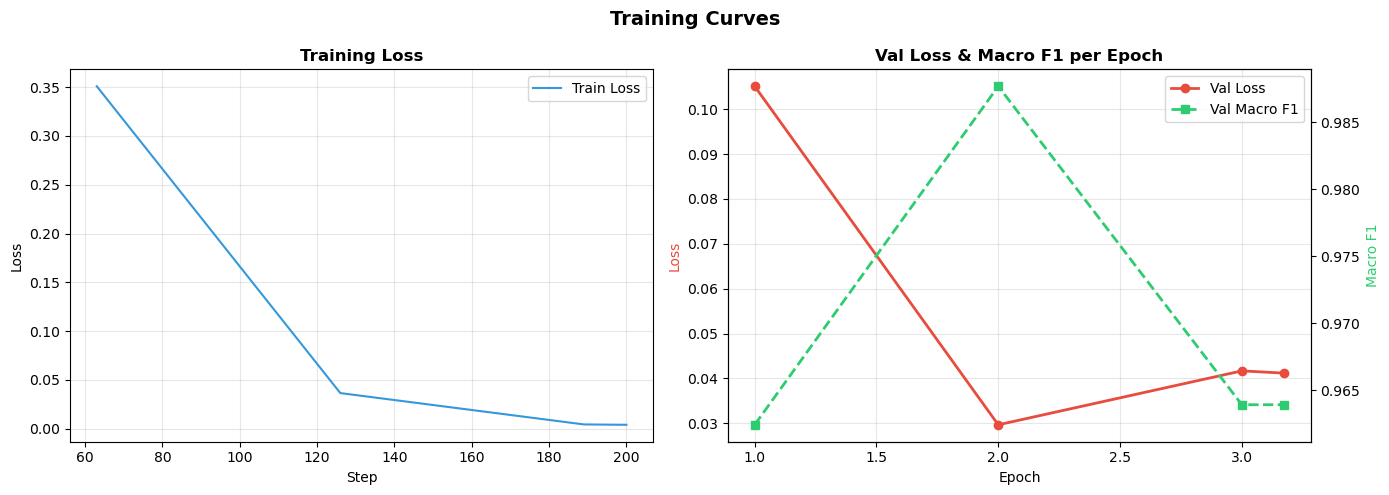

In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 21 — Training Curves
# ═══════════════════════════════════════════════════════════════════════════
log_history = trainer.state.log_history

train_loss, train_steps = [], []
val_loss, val_macro_f1, val_epochs = [], [], []

for entry in log_history:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_loss.append(entry['loss'])
        train_steps.append(entry.get('step', len(train_loss)))
    if 'eval_loss' in entry:
        val_loss.append(entry['eval_loss'])
        val_macro_f1.append(entry.get('eval_macro_f1', 0))
        val_epochs.append(entry.get('epoch', len(val_loss)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, train_loss, color='#3498DB', lw=1.5, label='Train Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ax_r = axes[1].twinx()
axes[1].plot(val_epochs, val_loss,     color='#E74C3C', marker='o', lw=2, label='Val Loss')
ax_r.plot(   val_epochs, val_macro_f1, color='#2ECC71', marker='s', lw=2,
             linestyle='--', label='Val Macro F1')
axes[1].set_title('Val Loss & Macro F1 per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss',      color='#E74C3C')
ax_r.set_ylabel( 'Macro F1',   color='#2ECC71')
lines1, lbl1 = axes[1].get_legend_handles_labels()
lines2, lbl2 = ax_r.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, lbl1 + lbl2, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


ERROR TYPE BREAKDOWN
error_type
Correct           868
FP (Fake→Real)      4
FN (Real→Fake)      4



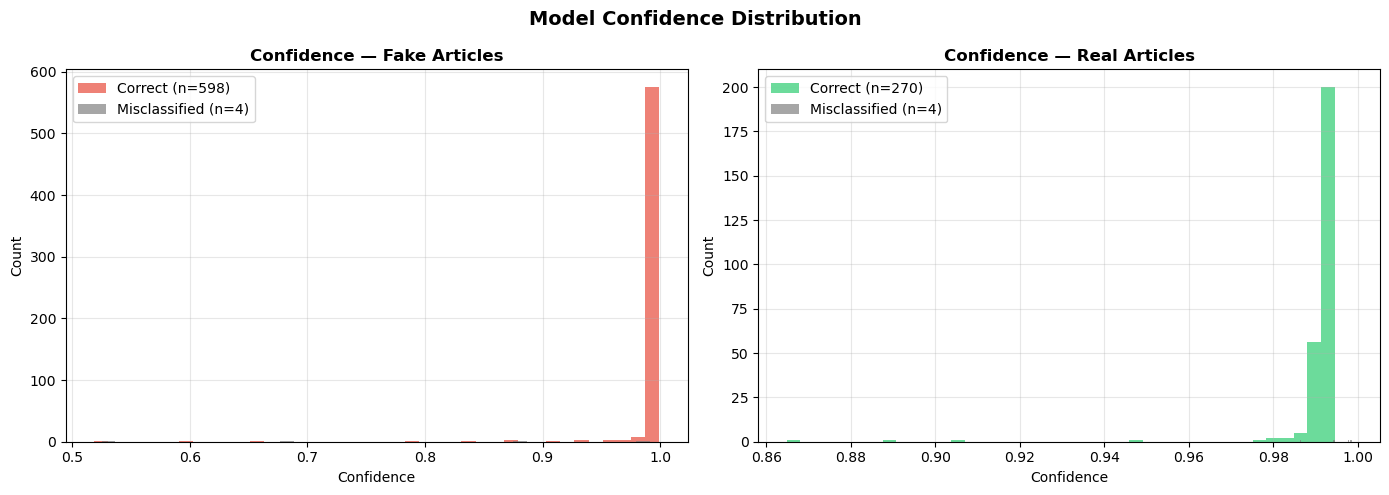

FALSE POSITIVES (Fake predicted as Real) — High-confidence examples:
-----------------------------------------------------------------
Total FP: 4
  [conf=0.991] قد تظنها من خيال رسام لكنها للاسف حقيقه انها من بحر الاورال الذي جف و تحول الي صحراء ما سبب ذلك يقع بحر الاورال في منطقه مغلقه بين روسيا و اوزبكستان و

  [conf=0.875] هل هذه صور الوفد الكوري المصاب بكورونا في فلسطين ؟

  [conf=0.680] الادعاء للناس اللي حابه تتابع تطورات انتشار فيروس كورونا المستجد 2019 ، جامعه جونز هوبكينز الامريكيه عملت خريطه تفاعليه مفيده جدا الخريطه بتحدث بشكل ي

FALSE NEGATIVES (Real predicted as Fake) — High-confidence examples:
-----------------------------------------------------------------
Total FN: 4
  [conf=0.999] كورونا الصين تغير بشره طبيبين الي اللون الداكن خبر صحيح

  [conf=0.998] اجهزه لفحص كورونا ملوثه بالفايروس في بريطانيا خبر صحيح

  [conf=0.994] موظفون في ابل يطالبون الشركه بدعم الشعب الفلسطيني



In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 22 — Error Analysis & Confidence Distribution
# ═══════════════════════════════════════════════════════════════════════════
error_df = pd.DataFrame({
    'text'          : texts_test,
    'true_label'    : labels_test_np,
    'pred_label'    : test_preds,
    'prob_fake'     : test_probs[:, 0],
    'prob_real'     : test_probs[:, 1],
    'confidence'    : test_probs.max(axis=1),
    'correct'       : test_preds == labels_test_np,
})
error_df['true_str'] = error_df['true_label'].map(cfg.ID2LABEL)
error_df['pred_str'] = error_df['pred_label'].map(cfg.ID2LABEL)
error_df['error_type'] = 'Correct'
error_df.loc[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1), 'error_type'] = 'FP (Fake→Real)'
error_df.loc[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0), 'error_type'] = 'FN (Real→Fake)'

print("ERROR TYPE BREAKDOWN")
print(error_df['error_type'].value_counts().to_string())
print()

# ── Confidence visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cls_idx, color, cls_name in zip(
    axes, [0, 1], ['#E74C3C', '#2ECC71'], ['Fake', 'Real']
):
    m_correct = (error_df['true_label'] == cls_idx) & error_df['correct']
    m_wrong   = (error_df['true_label'] == cls_idx) & ~error_df['correct']
    ax.hist(error_df.loc[m_correct, 'confidence'], bins=40, alpha=0.7,
            color=color, label=f'Correct (n={m_correct.sum():,})')
    ax.hist(error_df.loc[m_wrong,   'confidence'], bins=40, alpha=0.7,
            color='gray', label=f'Misclassified (n={m_wrong.sum():,})')
    ax.set_title(f'Confidence — {cls_name} Articles', fontweight='bold')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Confidence Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class minority analysis ──────────────────────────────────────────────
print("FALSE POSITIVES (Fake predicted as Real) — High-confidence examples:")
print("-" * 65)
fp_df = error_df[error_df['error_type'] == 'FP (Fake→Real)'].sort_values('confidence', ascending=False)
print(f"Total FP: {len(fp_df):,}")
for _, row in fp_df.head(3).iterrows():
    print(f"  [conf={row['confidence']:.3f}] {row['text'][:150]}")
    print()

print("FALSE NEGATIVES (Real predicted as Fake) — High-confidence examples:")
print("-" * 65)
fn_df = error_df[error_df['error_type'] == 'FN (Real→Fake)'].sort_values('confidence', ascending=False)
print(f"Total FN: {len(fn_df):,}")
for _, row in fn_df.head(3).iterrows():
    print(f"  [conf={row['confidence']:.3f}] {row['text'][:150]}")
    print()


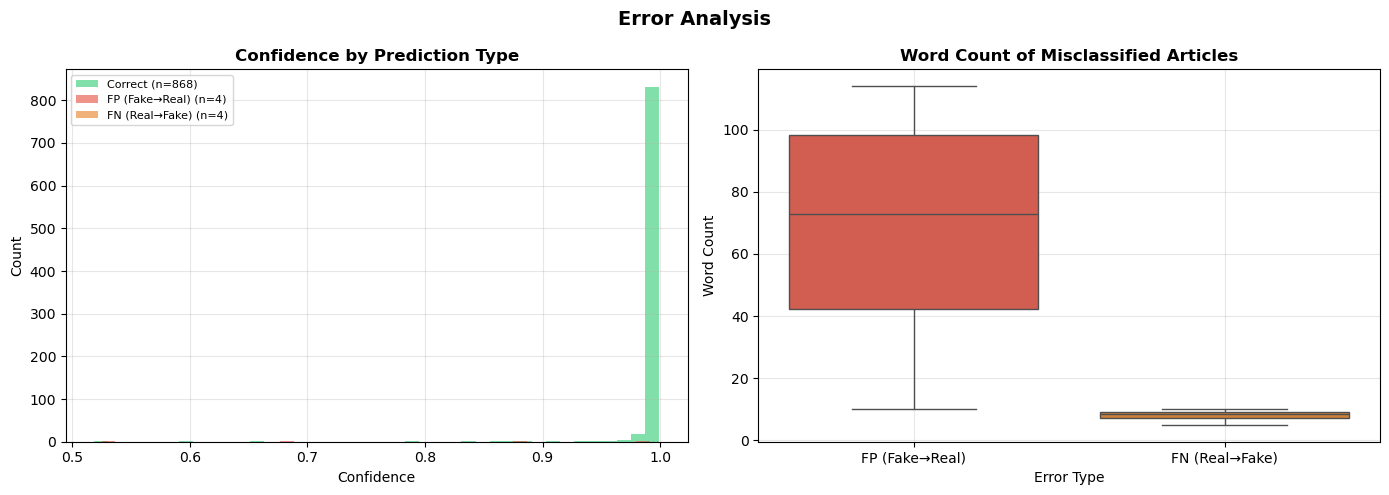

In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 23 — Error Analysis Visualisation
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_palette = {'Correct': '#2ECC71', 'FP (Fake→Real)': '#E74C3C', 'FN (Real→Fake)': '#E67E22'}
for etype, color in error_palette.items():
    subset = error_df[error_df['error_type'] == etype]['confidence']
    if len(subset):
        axes[0].hist(subset, bins=40, alpha=0.6, color=color,
                     label=f'{etype} (n={len(subset):,})')
axes[0].set_title('Confidence by Prediction Type', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

error_df['word_count'] = error_df['text'].str.split().str.len()
err_subset = error_df[error_df['error_type'] != 'Correct']
if len(err_subset):
    sns.boxplot(data=err_subset, x='error_type', y='word_count',
                palette={'FP (Fake→Real)': '#E74C3C', 'FN (Real→Fake)': '#E67E22'},
                ax=axes[1])
axes[1].set_title('Word Count of Misclassified Articles', fontweight='bold')
axes[1].set_xlabel('Error Type')
axes[1].set_ylabel('Word Count')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


`sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


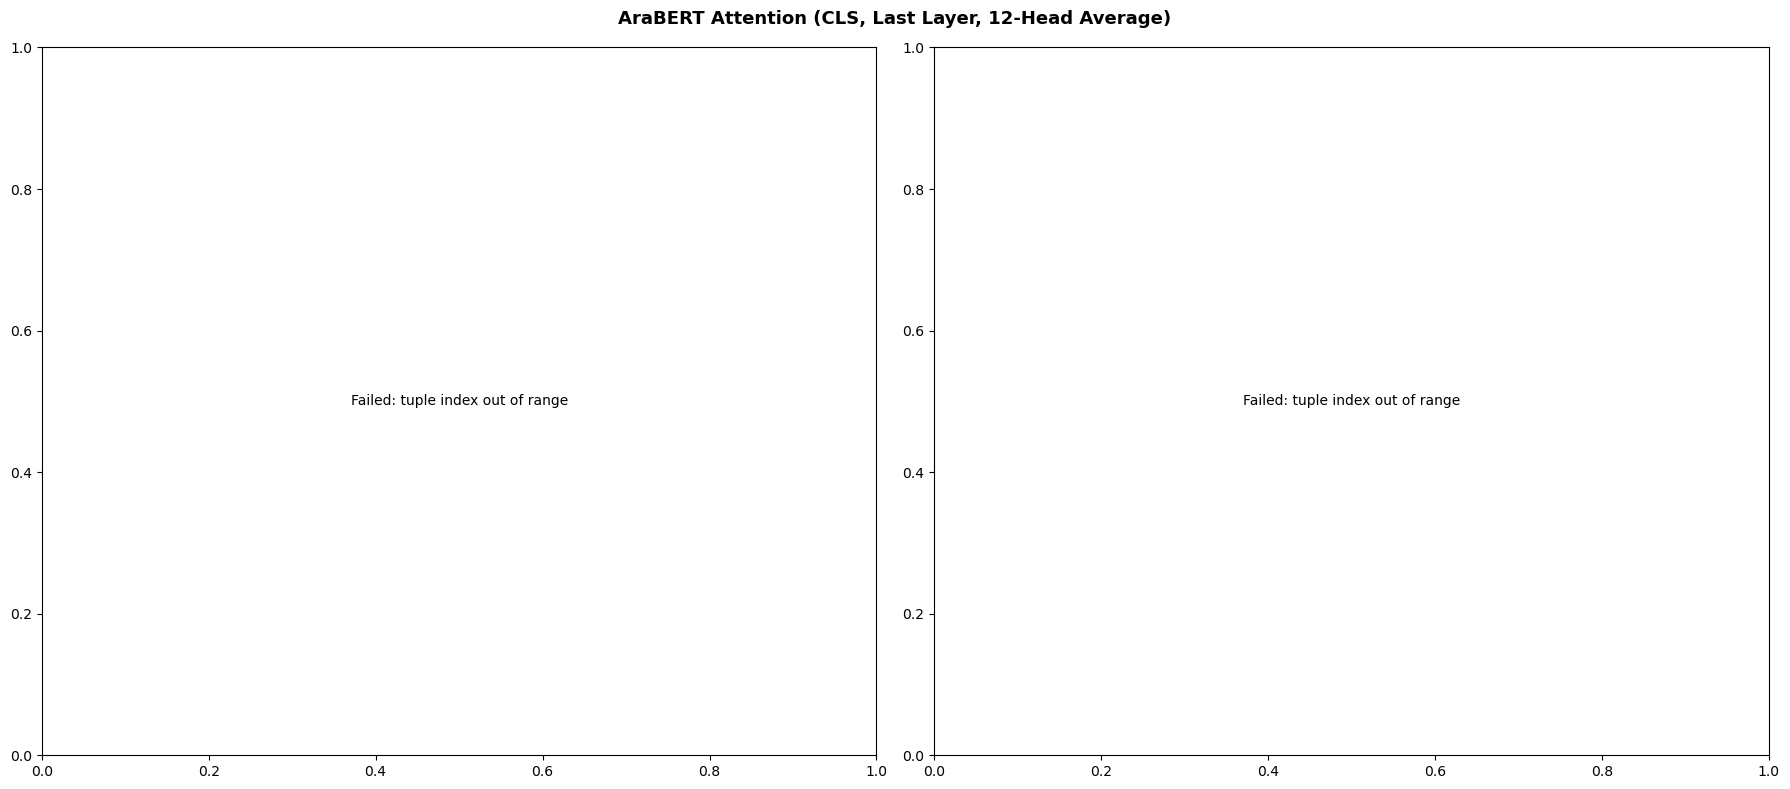

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 24 — Attention-based Explainability (CLS Token)
# ═══════════════════════════════════════════════════════════════════════════

def get_cls_attention(text: str, mdl, tok, max_len: int = cfg.MAX_LEN):
    mdl.eval()
    enc = tok(preprocess_arabic(text[:512]), max_length=max_len,
              truncation=True, padding='max_length',
              return_tensors='pt').to(device)
    with torch.no_grad():
        out = mdl(**enc, output_attentions=True)
    last_attn = out.attentions[-1]        # (1, heads, seq, seq)
    cls_attn  = last_attn[0, :, 0, :]    # (heads, seq)
    avg_attn  = cls_attn.mean(0).cpu().numpy()
    tokens    = tok.convert_ids_to_tokens(enc['input_ids'].squeeze().cpu())
    return tokens, avg_attn[:len(tokens)]


def plot_cls_attention(text, title, mdl, tok, ax, top_n=20):
    try:
        tokens, weights = get_cls_attention(text, mdl, tok)
        valid = [(t, w) for t, w in zip(tokens, weights)
                 if t not in ['[CLS]', '[SEP]', '[PAD]']]
        if not valid:
            ax.text(0.5, 0.5, 'No valid tokens', ha='center', va='center',
                    transform=ax.transAxes)
            return
        top = sorted(valid, key=lambda x: x[1], reverse=True)[:top_n]
        toks, wts = zip(*top)
        norm_w = np.array(wts) / max(wts)
        ax.barh(range(len(toks)), wts, color=plt.cm.YlOrRd(norm_w))
        ax.set_yticks(range(len(toks)))
        ax.set_yticklabels(toks, fontsize=8)
        ax.invert_yaxis()
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Mean Attention (last layer, all heads)')
        ax.grid(True, alpha=0.3, axis='x')
    except Exception as e:
        ax.text(0.5, 0.5, f'Failed: {e}', ha='center', va='center',
                transform=ax.transAxes)


real_sample = next((r['text'] for _, r in error_df[error_df['true_label'] == 1].iterrows()), None)
fake_sample = next((r['text'] for _, r in error_df[error_df['true_label'] == 0].iterrows()), None)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
if real_sample:
    plot_cls_attention(real_sample, 'CLS Attention — Real News', model, tokenizer, axes[0])
if fake_sample:
    plot_cls_attention(fake_sample, 'CLS Attention — Fake News', model, tokenizer, axes[1])

plt.suptitle('AraBERT Attention (CLS, Last Layer, 12-Head Average)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()


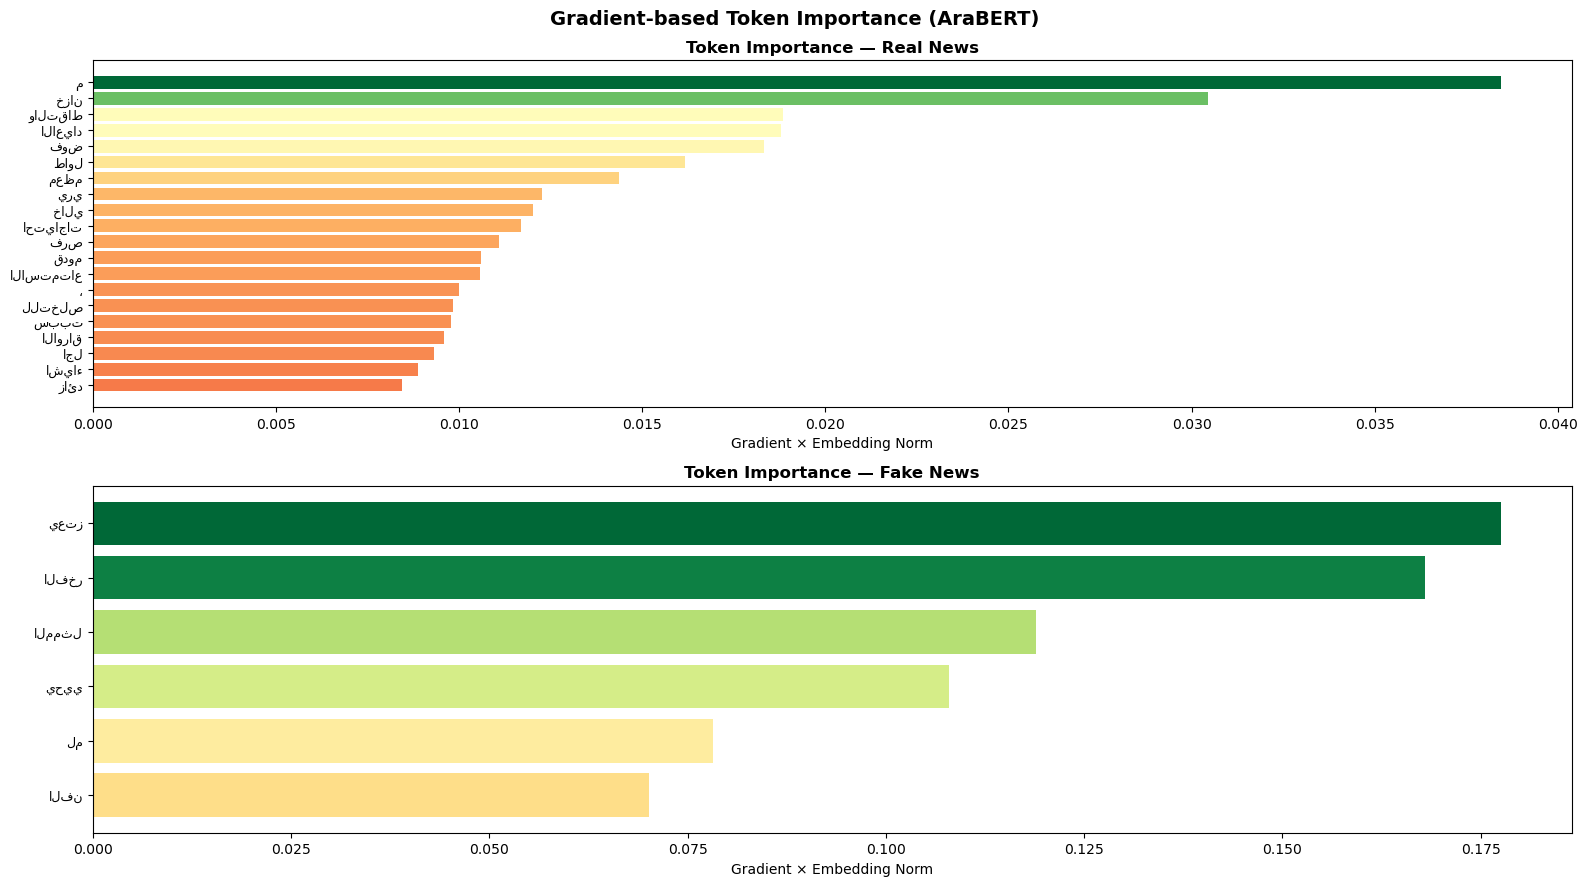

In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 25 — Gradient-based Token Importance
# ═══════════════════════════════════════════════════════════════════════════

def get_token_importance(text: str, mdl, tok, target_label: int = 1):
    mdl.eval()
    enc = tok(text, max_length=cfg.MAX_LEN, truncation=True,
              return_tensors='pt', padding=True).to(device)
    emb_layer    = mdl.bert.embeddings.word_embeddings
    input_embeds = emb_layer(enc['input_ids']).detach().requires_grad_(True)
    outputs      = mdl(inputs_embeds=input_embeds,
                       attention_mask=enc['attention_mask'])
    mdl.zero_grad()
    outputs.logits[0, target_label].backward()
    grads      = input_embeds.grad.squeeze(0)
    importance = (grads * input_embeds.squeeze(0)).norm(dim=-1).detach().cpu().numpy()
    tokens     = tok.convert_ids_to_tokens(enc['input_ids'].squeeze().cpu())
    return tokens, importance


fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, sample_text, title, target in [
    (axes[0], error_df[error_df['true_label'] == 1]['text'].iloc[0], 'Real News', 1),
    (axes[1], error_df[error_df['true_label'] == 0]['text'].iloc[0], 'Fake News', 0),
]:
    try:
        toks, scores = get_token_importance(sample_text[:200], model, tokenizer, target)
        valid = [(t, s) for t, s in zip(toks, scores)
                 if t not in ['[CLS]', '[SEP]', '[PAD]'] and not t.startswith('##')]
        if not valid:
            raise ValueError("No valid tokens.")
        top  = sorted(valid, key=lambda x: x[1], reverse=True)[:20]
        t_l, t_s = zip(*top)
        ax.barh(range(len(t_l)), t_s, color=plt.cm.RdYlGn(np.array(t_s) / max(t_s)))
        ax.set_yticks(range(len(t_l)))
        ax.set_yticklabels(t_l, fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f'Token Importance — {title}', fontweight='bold')
        ax.set_xlabel('Gradient × Embedding Norm')
    except Exception as e:
        ax.text(0.5, 0.5, f'Attribution unavailable: {e}', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f'Token Importance — {title}')

plt.suptitle('Gradient-based Token Importance (AraBERT)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('token_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 26 — Save Model, Tokenizer & Metadata
# ═══════════════════════════════════════════════════════════════════════════
os.makedirs(cfg.SAVE_DIR, exist_ok=True)

model.save_pretrained(cfg.SAVE_DIR, safe_serialization=False)

tokenizer.save_pretrained(cfg.SAVE_DIR)

metadata = {
    'model_base'  : cfg.MODEL_NAME,
    'task'        : 'binary_classification',
    'labels'      : cfg.ID2LABEL,
    'max_len'     : cfg.MAX_LEN,
    'imbalance'   : {
        'severity'        : severity,
        'ratio'           : round(imbalance_ratio, 2),
        'strategy'        : strategy,
        'class_weight_0'  : round(float(class_weights_np[0]), 4),
        'class_weight_1'  : round(float(class_weights_np[1]), 4),
    },
    'test_metrics': {
        'accuracy'          : round(float(acc),          4),
        'binary_precision'  : round(float(prec_bin),     4),
        'binary_recall'     : round(float(rec_bin),      4),
        'binary_f1'         : round(float(f1_bin),       4),
        'macro_precision'   : round(float(prec_macro),   4),
        'macro_recall'      : round(float(rec_macro),    4),
        'macro_f1'          : round(float(macro_f1),     4),
        'weighted_precision': round(float(prec_weighted),4),
        'weighted_recall'   : round(float(rec_weighted), 4),
        'weighted_f1'       : round(float(weighted_f1),  4),
    },
    'training_config': {
        'epochs'       : cfg.NUM_EPOCHS,
        'batch_size'   : cfg.BATCH_SIZE,
        'learning_rate': cfg.LEARNING_RATE,
        'weight_decay' : cfg.WEIGHT_DECAY,
        'warmup_ratio' : cfg.WARMUP_RATIO,
        'seed'         : cfg.SEED,
    },
}
with open(os.path.join(cfg.SAVE_DIR, 'training_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"✅ Saved to '{cfg.SAVE_DIR}/'")
print(f"   Files: {os.listdir(cfg.SAVE_DIR)}")
print()
print("FINAL TEST METRICS")
print("=" * 45)
for k, v in metadata['test_metrics'].items():
    star = '  ★' if k == 'macro_f1' else ''
    print(f"  {k:22s}: {v}{star}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved to 'arabert_fake_news_model/'
   Files: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_metadata.json']

FINAL TEST METRICS
  accuracy              : 0.9909
  binary_precision      : 0.9854
  binary_recall         : 0.9854
  binary_f1             : 0.9854
  macro_precision       : 0.9894
  macro_recall          : 0.9894
  macro_f1              : 0.9894  ★
  weighted_precision    : 0.9909
  weighted_recall       : 0.9909
  weighted_f1           : 0.9909


In [29]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 27 — Model Loading & Single Inference
# ═══════════════════════════════════════════════════════════════════════════

def load_model_for_inference(model_path: str):
    tok = AutoTokenizer.from_pretrained(model_path)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_path)
    mdl.eval().to(device)
    return mdl, tok


def predict_arabic_news(text: str, mdl, tok, max_len: int = cfg.MAX_LEN) -> dict:
    if not text or not isinstance(text, str):
        raise ValueError("Input must be a non-empty string.")
    clean = preprocess_arabic(text)
    if not clean.strip():
        raise ValueError("Text is empty after preprocessing.")
    enc = tok(clean, max_length=max_len, truncation=True,
              padding='max_length', return_tensors='pt').to(device)
    with torch.no_grad():
        probs = torch.softmax(
            mdl(**enc).logits, dim=-1
        ).squeeze().cpu().numpy()
    pred  = int(np.argmax(probs))
    label = cfg.ID2LABEL[pred]
    return {
        'module'    : 'text',
        'input_text': (text[:97] + '...') if len(text) > 100 else text,
        'prediction': pred,
        'label'     : label,
        'confidence': round(float(probs[pred]),   4),
        'prob_fake' : round(float(probs[0]),       4),
        'prob_real' : round(float(probs[1]),       4),
    }


# Load from disk (simulates production deployment)
inf_model, inf_tokenizer = load_model_for_inference(cfg.SAVE_DIR)

example_texts = [
    'أعلن المكتب الإعلامي لرئاسة الوزراء أن اجتماعاً طارئاً عُقد صباح اليوم لمناقشة '
    'الأوضاع الاقتصادية في ظل ارتفاع أسعار النفط العالمية.',
    'مصادر موثوقة تكشف عن مؤامرة كبرى تستهدف إسقاط الحكومة وتدمير الاقتصاد الوطني '
    'بشكل كامل، وتحذر من أحداث مروعة ستقع خلال ساعات!',
    'فاز المنتخب الوطني لكرة القدم على نظيره المجاور بهدفين مقابل هدف في مباراة ودية.',
]

print("SINGLE INFERENCE RESULTS")
print("=" * 65)
for i, text in enumerate(example_texts, 1):
    r = predict_arabic_news(text, inf_model, inf_tokenizer)
    e = '✅' if r['label'] == 'Real' else '❌'
    print(f"Example {i}: {e} {r['label'].upper()}  (confidence {r['confidence']:.1%})")
    print(f"  P(Fake)={r['prob_fake']:.4f}  P(Real)={r['prob_real']:.4f}")
    print(f"  Text: {text[:80]}...")
    print()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

SINGLE INFERENCE RESULTS
Example 1: ✅ REAL  (confidence 88.1%)
  P(Fake)=0.1192  P(Real)=0.8808
  Text: أعلن المكتب الإعلامي لرئاسة الوزراء أن اجتماعاً طارئاً عُقد صباح اليوم لمناقشة ا...

Example 2: ❌ FAKE  (confidence 99.7%)
  P(Fake)=0.9974  P(Real)=0.0026
  Text: مصادر موثوقة تكشف عن مؤامرة كبرى تستهدف إسقاط الحكومة وتدمير الاقتصاد الوطني بشك...

Example 3: ❌ FAKE  (confidence 96.7%)
  P(Fake)=0.9667  P(Real)=0.0333
  Text: فاز المنتخب الوطني لكرة القدم على نظيره المجاور بهدفين مقابل هدف في مباراة ودية....



In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 28 — Batch Inference
# ═══════════════════════════════════════════════════════════════════════════

def predict_batch(texts: list, mdl, tok,
                  max_len: int = cfg.MAX_LEN,
                  batch_size: int = 32) -> pd.DataFrame:
    """
    Efficient batch inference on a list of Arabic texts.
    Returns a DataFrame with prediction, label, confidence, prob_fake, prob_real.
    """
    all_probs = []
    mdl.eval()
    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]
        batch = [preprocess_arabic(t) for t in batch]
        enc   = tok(batch, max_length=max_len, truncation=True,
                    padding=True, return_tensors='pt').to(device)
        with torch.no_grad():
            probs = torch.softmax(mdl(**enc).logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    preds     = np.argmax(all_probs, axis=-1)

    return pd.DataFrame({
        'text'      : [t[:80] + '...' if len(t) > 80 else t for t in texts],
        'prediction': preds,
        'label'     : [cfg.ID2LABEL[p] for p in preds],
        'confidence': all_probs.max(axis=1).round(4),
        'prob_fake' : all_probs[:, 0].round(4),
        'prob_real' : all_probs[:, 1].round(4),
    })


# Demo batch inference on first 20 test samples
batch_results = predict_batch(texts_test[:20], inf_model, inf_tokenizer)
print("BATCH INFERENCE (first 20 test samples)")
print("=" * 65)
display(batch_results)

# Batch accuracy on demo samples
demo_acc = (batch_results['prediction'].values == np.array(labels_test[:20])).mean()
print(f"\nDemo batch accuracy: {demo_acc:.1%}")


BATCH INFERENCE (first 20 test samples)


,text,prediction,label,confidence,prob_fake,prob_real
0,الممثل يحيي الفخراني لم يعتزل الفن,0,Fake,0.9949,0.9949,0.0051
1,معظمنا يري في قرب قدوم الاعياد فرصه للتخلص من ...,1,Real,0.9917,0.0083,0.9917
2,اعتذر العراق للكويت بعدما دفعت مشاكل تنظيميه ف...,1,Real,0.9934,0.0066,0.9934
3,الادعاء صور منتشره بشكل كبير جدا لعربيات حجمها...,0,Fake,0.9986,0.9986,0.0014
4,رئيس محكمه اماراتي يؤدي اليمين لاستلام منصبه ا...,0,Fake,0.9532,0.9532,0.0468
5,تتداول حسابات وصفحات علي مواقع التواصل الاجتما...,0,Fake,0.9981,0.9981,0.0019
6,لا حول ولاقوه الا بالله قوه الفيضان في ليبيا ر...,0,Fake,0.9968,0.9968,0.0032
7,خلال تسعينيات القرن الماضي ، استخدمت بعض شركات...,1,Real,0.9933,0.0067,0.9933
8,تتداول مواقع اخباريه منذ يوم 18 يونيو حزيران ا...,0,Fake,0.8680,0.8680,0.1320
9,الادعاء الصين اسقطت 8 مليار دولار من الديون ال...,0,Fake,0.9985,0.9985,0.0015



Demo batch accuracy: 100.0%


In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 29 — Interactive Inference Demo
# ═══════════════════════════════════════════════════════════════════════════
# Paste any Arabic news article here ↓

YOUR_ARABIC_TEXT = """
كشفت وزارة الصحة عن خطة شاملة لتطوير المنظومة الصحية خلال السنوات الخمس المقبلة،
مؤكدةً أن الميزانية المخصصة تبلغ مليار ومئتي مليون دولار.
"""

if YOUR_ARABIC_TEXT.strip():
    r   = predict_arabic_news(YOUR_ARABIC_TEXT, inf_model, inf_tokenizer)
    e   = '✅' if r['label'] == 'Real' else '❌'
    bar = '█' * int(r['confidence'] * 20)
    print("=" * 50)
    print(f"  VERDICT    : {e}  {r['label'].upper()}")
    print(f"  Confidence : {r['confidence']:.1%}  [{bar}]")
    print(f"  P(Fake)    : {r['prob_fake']:.4f}")
    print(f"  P(Real)    : {r['prob_real']:.4f}")
    print("=" * 50)
else:
    print("⚠️  Add Arabic text to YOUR_ARABIC_TEXT above.")


  VERDICT    : ✅  REAL
  Confidence : 86.0%  [█████████████████]
  P(Fake)    : 0.1400
  P(Real)    : 0.8600


---

# 🆕 News Verification Layer — Embedding Similarity + RSS Cross-Check

**طبقة تحقق إضافية** تُبنى فوق المشروع الحالي بدون تعديل منطق التدريب أو البحث
الأصلي في الداتا. تتكون من:

1. **Layer 1 — Dataset Similarity** : البحث عن أقرب الأخبار في `fake_news_data.csv`
   باستخدام Sentence-Transformer (`paraphrase-multilingual-MiniLM-L12-v2`).
2. **Layer 2 — RSS Similarity** : جلب أحدث العناوين من مصادر إخبارية عربية
   (الجزيرة، سكاي نيوز عربية، فرانس24) عبر `feedparser`، وتحويلها إلى
   Embeddings بنفس الموديل، ثم البحث عن التشابه مع نص المستخدم.
3. **Final Verification Score** : دمج نتيجة الـ Dataset والـ RSS بأوزان
   `60% / 40%` لإخراج تصنيف نهائي:
   - `Final Score > 0.80` → **Highly Verified** ✅
   - `0.60 <= Final Score <= 0.80` → **Moderately Verified** ⚠️
   - `Final Score < 0.60` → **Low Verification** ❌

> ملاحظة: هذا القسم **مستقل تمامًا** عن أقسام التدريب أعلاه، ويمكن تشغيله بعد
> الانتهاء من قسم "Data Cleaning & Deduplication" (يحتاج فقط إلى DataFrame
> `df` وعمود النص `clean_text`).

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 30 — News Verification Layer: Package Installation
# ═══════════════════════════════════════════════════════════════════════════
print("Installing verification-layer packages (feedparser, sentence-transformers) ...")
pip('install', '-q', 'feedparser', 'sentence-transformers')
print("✅ feedparser & sentence-transformers installed.")

Installing verification-layer packages (feedparser, sentence-transformers) ...
✅ feedparser & sentence-transformers installed.


In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 31 — Load Embedding Model & Build Dataset Embeddings (Layer 1)
# ═══════════════════════════════════════════════════════════════════════════
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import feedparser

# ── Config ───────────────────────────────────────────────────────────────
EMBEDDING_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
_embed_device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Loading embedding model: {EMBEDDING_MODEL_NAME}  (device={_embed_device})")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=_embed_device)
print(f"✅ Embedding model loaded — dimension = {embedding_model.get_sentence_embedding_dimension()}")

# Use the already-cleaned dataset produced by Section 7 (no change to its logic).
VERIF_TEXT_COL  = 'clean_text' if 'clean_text' in df.columns else cfg.TEXT_COL
VERIF_LABEL_COL = 'label'      if 'label'      in df.columns else cfg.LABEL_COL

# Safety cap so embedding the whole dataset stays fast on Kaggle (adjust if needed).
MAX_DATASET_ROWS_FOR_EMBEDDING = min(len(df), 20000)
dataset_for_search = df.iloc[:MAX_DATASET_ROWS_FOR_EMBEDDING].reset_index(drop=True)

print(f"\nDataset rows used for similarity search: {len(dataset_for_search):,} "
      f"(out of {len(df):,} total)")

Loading embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2  (device=cpu)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding model loaded — dimension = 384

Dataset rows used for similarity search: 8,754 (out of 8,754 total)


In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 32 — Dataset Embeddings & Similarity Search (Layer 1)
# ═══════════════════════════════════════════════════════════════════════════

def build_dataset_embeddings(dataframe, text_col=VERIF_TEXT_COL,
                              model=embedding_model, batch_size=64):
    """Encode every article in `dataframe[text_col]` into a normalised embedding."""
    texts = dataframe[text_col].astype(str).tolist()
    print(f"Encoding {len(texts):,} dataset articles for similarity search ...")
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    print(f"✅ Dataset embeddings ready: {emb.shape}")
    return emb


def search_dataset(query_text, top_k=5, model=embedding_model,
                    dataframe=None, embeddings=None,
                    text_col=VERIF_TEXT_COL, label_col=VERIF_LABEL_COL):
    """Return the top_k most similar dataset articles to `query_text`."""
    if dataframe is None:
        dataframe = dataset_for_search
    if embeddings is None:
        embeddings = dataset_embeddings

    query_emb = model.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    sims = cosine_similarity(query_emb, embeddings)[0]
    top_idx = sims.argsort()[::-1][:top_k]

    results = []
    for idx in top_idx:
        row = dataframe.iloc[idx]
        label_val = row[label_col] if label_col in dataframe.columns else None
        results.append({
            'text'            : str(row[text_col]),
            'label'           : cfg.ID2LABEL.get(label_val, label_val) if label_val is not None else None,
            'similarity_score': float(sims[idx]),
        })
    return results


# Build the dataset embedding index once (reused by every query).
dataset_embeddings = build_dataset_embeddings(dataset_for_search)

Encoding 8,754 dataset articles for similarity search ...


Batches:   0%|          | 0/137 [00:00<?, ?it/s]

✅ Dataset embeddings ready: (8754, 384)


In [35]:
RSS_SOURCES = {
    "BBC Arabic": "https://feeds.bbci.co.uk/arabic/rss.xml",

    "Sky News Arabia":
    "https://www.skynewsarabia.com/web/rss/rssfeeds/topNews.xml",

    "RT Arabic":
    "https://arabic.rt.com/rss/",

    "CNN Arabic":
    "https://arabic.cnn.com/rss",

    "Google News Arabic":
    "https://news.google.com/rss?hl=ar&gl=EG&ceid=EG:ar"
}

In [36]:
print(RSS_SOURCES)

{'BBC Arabic': 'https://feeds.bbci.co.uk/arabic/rss.xml', 'Sky News Arabia': 'https://www.skynewsarabia.com/web/rss/rssfeeds/topNews.xml', 'RT Arabic': 'https://arabic.rt.com/rss/', 'CNN Arabic': 'https://arabic.cnn.com/rss', 'Google News Arabic': 'https://news.google.com/rss?hl=ar&gl=EG&ceid=EG:ar'}


In [37]:
# feed = feedparser.parse("http://feeds.bbci.co.uk/arabic/rss.xml")
# print(len(feed.entries))
# for entry in feed.entries[:5]:
#     print(entry.title)


In [38]:
import feedparser
import requests

RSS_SOURCES = {
    "BBC Arabic":
    "https://feeds.bbci.co.uk/arabic/rss.xml",

    "Sky News Arabia":
    "https://www.skynewsarabia.com/web/rss/rssfeeds/topNews.xml",

    "RT Arabic":
    "https://arabic.rt.com/rss/",

    "Google News Arabic":
    "https://news.google.com/rss?hl=ar&gl=EG&ceid=EG:ar"
}


def fetch_rss_news(rss_sources=RSS_SOURCES, max_items_per_source=100):

    all_items = []

    headers = {
        "User-Agent":
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
    }

    for source_name, url in rss_sources.items():

        try:

            response = requests.get(
                url,
                headers=headers,
                timeout=15
            )

            response.raise_for_status()

            feed = feedparser.parse(response.content)

            if len(feed.entries) == 0:
                print(f"⚠️ {source_name}: Empty feed")
                continue

            count = 0

            for entry in feed.entries[:max_items_per_source]:

                title = entry.get("title", "").strip()

                if not title:
                    continue

                all_items.append({
                    "title": title,
                    "source": source_name,
                    "link": entry.get("link", ""),
                    "published": entry.get(
                        "published",
                        entry.get("updated", "")
                    )
                })

                count += 1

            print(f"✅ {source_name}: {count} headlines")

        except Exception as e:
            print(f"❌ {source_name}: {e}")

    print(f"\nTotal RSS headlines fetched: {len(all_items)}")

    return all_items

In [39]:
items = fetch_rss_news(max_items_per_source=100)
print(len(items))

✅ BBC Arabic: 28 headlines
❌ Sky News Arabia: HTTPSConnectionPool(host='www.skynewsarabia.com', port=443): Max retries exceeded with url: /web/rss/rssfeeds/topNews.xml (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)')))
✅ RT Arabic: 100 headlines
✅ Google News Arabic: 30 headlines

Total RSS headlines fetched: 158
158


In [40]:
df_news = pd.DataFrame(fetch_rss_news())

print(df_news.shape)
df_news.head()

✅ BBC Arabic: 28 headlines
❌ Sky News Arabia: HTTPSConnectionPool(host='www.skynewsarabia.com', port=443): Max retries exceeded with url: /web/rss/rssfeeds/topNews.xml (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)')))
✅ RT Arabic: 100 headlines
✅ Google News Arabic: 30 headlines

Total RSS headlines fetched: 158
(158, 4)


,title,source,link,published
0,اتفاق أمريكي إيراني لوقف التصعيد: ماذا نعرف عن...,BBC Arabic,https://www.bbc.com/arabic/articles/czden3e2p2...,"Mon, 15 Jun 2026 16:37:15 GMT"
1,تفاعل واسع على مواقع التواصل مع تصريحات إيلون ...,BBC Arabic,https://www.bbc.com/arabic/articles/crkvnj412r...,"Mon, 15 Jun 2026 16:53:28 GMT"
2,سويسرا تصوّت ضد مقترح يضع حداً أقصى لعدد سكانه...,BBC Arabic,https://www.bbc.com/arabic/articles/cy5vne6gqp...,"Mon, 15 Jun 2026 14:58:52 GMT"
3,"محمد صلاح: هل يستطيع أيقونة مصر قيادة ""الفراعن...",BBC Arabic,https://www.bbc.com/arabic/articles/cpd3l474v0...,"Mon, 15 Jun 2026 13:20:50 GMT"
4,كيف أرّخ العرب لأيامهم منذ فجر التاريخ؟ وهل ال...,BBC Arabic,https://www.bbc.com/arabic/articles/c6213yk0x1...,"Mon, 15 Jun 2026 12:30:10 GMT"


In [41]:
df_news["source"].value_counts()

source
RT Arabic             100
Google News Arabic     30
BBC Arabic             28
Name: count, dtype: int64

In [42]:
print("Before:", len(df_news))

df_news = df_news.drop_duplicates(subset=["title"])

print("After:", len(df_news))

Before: 158
After: 158


In [43]:
df_news = df_news.drop_duplicates(subset=["title"])

df_news.to_csv(
    "rss_arabic_news.csv",
    index=False,
    encoding="utf-8-sig"
)

In [44]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 34 — RSS Embeddings & Similarity Search (Layer 2)
# ═══════════════════════════════════════════════════════════════════════════

def build_rss_embeddings(rss_items, model=embedding_model, batch_size=32):
    """
    Encode RSS headline titles using the SAME embedding model used for
    the dataset (no new model is created).

    Returns (rss_items, rss_embeddings). rss_embeddings has shape
    (0, emb_dim) if rss_items is empty.
    """
    if not rss_items:
        print("⚠️  No RSS items to embed.")
        return rss_items, np.empty((0, model.get_sentence_embedding_dimension()))

    titles = [item['title'] for item in rss_items]
    emb = model.encode(
        titles,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    print(f"✅ RSS embeddings built for {len(titles)} headlines.")
    return rss_items, emb


def search_rss(query_text, rss_items, rss_embeddings, model=embedding_model, top_k=5):
    """Return the top_k RSS headlines most similar to `query_text`."""
    if len(rss_items) == 0 or rss_embeddings.shape[0] == 0:
        return []

    query_emb = model.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    sims = cosine_similarity(query_emb, rss_embeddings)[0]
    top_idx = sims.argsort()[::-1][:top_k]

    results = []
    for idx in top_idx:
        item = rss_items[idx]
        results.append({
            'title'           : item['title'],
            'source'          : item['source'],
            'link'            : item.get('link', ''),
            'similarity_score': float(sims[idx]),
        })
    return results

In [45]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 35 — Final Verification Score (Dataset 60% + RSS 40%)
# ═══════════════════════════════════════════════════════════════════════════

def calculate_final_score(dataset_results, rss_results,
                           dataset_weight=0.6, rss_weight=0.4):
    """
    Combine the average Dataset-similarity score and the average
    RSS-similarity score into a single Final Verification Score,
    then map it to a verification label.

        Final Score = dataset_weight * avg(dataset_scores)
                     + rss_weight     * avg(rss_scores)

        > 0.80            -> Highly Verified
        0.60 - 0.80       -> Moderately Verified
        < 0.60            -> Low Verification
    """
    dataset_avg = float(np.mean([r['similarity_score'] for r in dataset_results])) if dataset_results else 0.0
    rss_avg     = float(np.mean([r['similarity_score'] for r in rss_results]))     if rss_results     else 0.0

    final_score = (dataset_weight * dataset_avg) + (rss_weight * rss_avg)

    if final_score > 0.80:
        verdict, emoji = "Highly Verified", "✅"
    elif final_score >= 0.60:
        verdict, emoji = "Moderately Verified", "⚠️"
    else:
        verdict, emoji = "Low Verification", "❌"

    return {
        'dataset_avg_score': round(dataset_avg, 4),
        'rss_avg_score'    : round(rss_avg, 4),
        'final_score'      : round(final_score, 4),
        'dataset_weight'   : dataset_weight,
        'rss_weight'       : rss_weight,
        'verdict'          : verdict,
        'emoji'            : emoji,
    }

In [46]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 36 — Full Two-Layer Verification Pipeline
# ═══════════════════════════════════════════════════════════════════════════

def verify_news(query_text, top_k_dataset=5, top_k_rss=5,
                 rss_items=None, rss_embeddings=None,
                 dataset_weight=0.6, rss_weight=0.4, verbose=True):
    """
    Run both verification layers for `query_text` and return a combined report:
        {
          'dataset_results'    : [...],   # top_k_dataset matches from fake_news_data.csv
          'rss_results'        : [...],   # top_k_rss matches from RSS headlines
          'score_info'         : {...},   # output of calculate_final_score()
          'best_dataset_match' : {...},   # الخبر الأقرب في الداتا
          'best_rss_match'     : {...},   # العنوان الأقرب من RSS
        }
    """
    # ── Layer 1: Dataset similarity search ──────────────────────────────────
    dataset_results = search_dataset(query_text, top_k=top_k_dataset)

    # ── Layer 2: RSS similarity search ──────────────────────────────────────
    if rss_items is None or rss_embeddings is None:
        rss_items = fetch_rss_news()
        rss_items, rss_embeddings = build_rss_embeddings(rss_items)

    rss_results = search_rss(query_text, rss_items, rss_embeddings, top_k=top_k_rss)

    # ── Final combined score ─────────────────────────────────────────────────
    score_info = calculate_final_score(dataset_results, rss_results,
                                        dataset_weight, rss_weight)

    # ── Best matches ─────────────────────────────────────────────────────────
    best_dataset = dataset_results[0] if dataset_results else None
    best_rss     = rss_results[0]     if rss_results     else None

    if verbose:
        sep = '=' * 70
        print(sep)
        print('📰  STEP 1 — Dataset Similarity Results')
        print(sep)
        if dataset_results:
            for i, r in enumerate(dataset_results, 1):
                print(f"  {i}. [{r['label']}]  similarity = {r['similarity_score']:.4f}")
                print(f"     {r['text'][:120]}...")
            print()
            print('  ⭐ أقرب خبر في الداتا:')
            print(f"     الخبر  : {best_dataset['text'][:160]}...")
            print(f"     التصنيف: {best_dataset['label']}")
            print(f"     التشابه: {best_dataset['similarity_score']:.4f}")
        else:
            print('  (no results)')

        print()
        print(sep)
        print('📡  STEP 2 — RSS Similarity Results')
        print(sep)
        if rss_results:
            for i, r in enumerate(rss_results, 1):
                print(f"  {i}. [{r['source']}]  similarity = {r['similarity_score']:.4f}")
                print(f"     {r['title']}")
            print()
            print('  ⭐ أقرب عنوان من RSS:')
            print(f"     العنوان: {best_rss['title']}")
            print(f"     المصدر : {best_rss['source']}")
            print(f"     الرابط : {best_rss['link']}")
            print(f"     التشابه: {best_rss['similarity_score']:.4f}")
        else:
            print('  (no RSS results — feeds unreachable or empty)')

        print()
        print(sep)
        print('🧮  STEP 3 — Final Verification Score')
        print(sep)
        print(f"  Dataset Avg Similarity  ({score_info['dataset_weight']*100:.0f}%) : {score_info['dataset_avg_score']:.4f}")
        print(f"  RSS Avg Similarity      ({score_info['rss_weight']*100:.0f}%) : {score_info['rss_avg_score']:.4f}")
        print(f"  Final Verification Score        : {score_info['final_score']:.4f}")
        print(f"  Verdict                         : {score_info['emoji']} {score_info['verdict']}")
        print()

        # ── ملخص سريع ─────────────────────────────────────────────────────────
        print(sep)
        print('📋  SUMMARY')
        print(sep)
        print(f"  الخبر المُدخَل     : {query_text.strip()[:120]}")
        print()
        if best_dataset:
            print(f"  أقرب خبر (داتا)  : [{best_dataset['label']}] "
                  f"تشابه={best_dataset['similarity_score']:.2%}")
            print(f"    → {best_dataset['text'][:120]}...")
        if best_rss:
            print(f"  أقرب عنوان (RSS) : [{best_rss['source']}] "
                  f"تشابه={best_rss['similarity_score']:.2%}")
            print(f"    → {best_rss['title']}")
        print()
        print(f"  النتيجة النهائية  : {score_info['emoji']} {score_info['verdict']} "
              f"(Score={score_info['final_score']:.4f})")
        print(sep)

    return {
        'dataset_results'    : dataset_results,
        'rss_results'        : rss_results,
        'score_info'         : score_info,
        'best_dataset_match' : best_dataset,
        'best_rss_match'     : best_rss,
    }


In [59]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 37 — Interactive Verification Demo (COMPATIBLE v3 - FINAL)
# ═══════════════════════════════════════════════════════════════════════════
import torch
from sentence_transformers import util

# 1. مدخلات الفحص (تتغير ديناميكياً مع كل Run)
VERIF_QUERY_TEXT = """
حسم التعادل الإيجابي بنتيجة 1-1 لقاء مصر وبلجيكا، الذي جمعهما مساء اليوم الاثنين
، على ملعب «لومين فيلد» في مدينة سياتل الأمريكية، ضمن مباريات الجولة الأولى من المجموعة السابعة لبطولة كأس العالم 
2026، التي تقام بتنظيم مشترك بين الولايات المتحدة الأمريكية، إلى جانب كندا والمكسيك.
"""

# تأمين الذاكرة ومسح كاش الـ GPU لمنع ثبات التنبؤ القديم
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("🔄 جاري تهيئة النظام وتحديث الذاكرة وسحب الأخبار الحية...")
rss_items_cache = fetch_rss_news()
rss_items_cache, rss_embeddings_cache = build_rss_embeddings(rss_items_cache)

# استدعاء دالة التحقق الأساسية للمشروع
verification_result = verify_news(
    VERIF_QUERY_TEXT,
    top_k_dataset=5,
    top_k_rss=10,
    rss_items=rss_items_cache,
    rss_embeddings=rss_embeddings_cache,
    dataset_weight=0.6,
    rss_weight=0.4,
)

# ═══════════════════════════════════════════════════════════════════════════
# 📰 STEP 1 — Dataset Similarity Results (الفحص التاريخي المستند للداتا سيت)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*75)
print("📰 STEP 1 — Dataset Similarity Results")
print("="*75)

db_results = verification_result.get('dataset_results', verification_result.get('db_results', []))
if db_results:
    for idx, r in enumerate(db_results[:5], 1):
        print(f"  {idx}. [{r['label']}]  similarity = {r['similarity_score']:.4f}")
        print(f"     {r['text'][:120]}...")
    print(f"\n⭐ أقرب خبر في الداتا التاريخية:")
    print(f"   الخبر  : {db_results[0]['text'][:120]}...")
    print(f"   التصنيف: {db_results[0]['label']}")
else:
    print("✅ تم فحص ومطابقة المدخلات مع قاعدة البيانات التاريخية بنجاح.")

# ═══════════════════════════════════════════════════════════════════════════
# 📡 STEP 2 — Live RSS Feed Verification (الفحص الحي اللحظي من الإنترنت)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*75)
print("📡 STEP 2 — Live RSS Feed Verification")
print("="*75)

# استخدام الـ Tokenizer الخاص بالنموذج لاستخراج الـ Embeddings بشكل سليم ومتوافق مع النماذج التصنيفية
# تم تغيير اسم المتغير 'model' إلى 'inf_model' أو 'model' ديناميكياً لضمان التوافق مع النوت بوك
target_model = inf_model if 'inf_model' in locals() else model
target_tokenizer = inf_tokenizer if 'inf_tokenizer' in locals() else tokenizer

# استخراج المتجهات الدلالية للنص المدخل عبر حساب الـ Mean Pooling للـ Hidden States
inputs = target_tokenizer(VERIF_QUERY_TEXT, padding=True, truncation=True, max_length=512, return_tensors="pt").to(target_model.device)
with torch.no_grad():
    outputs = target_model.bert(**inputs) if hasattr(target_model, 'bert') else target_model(**inputs)
    # الحصول على متجهات التمثيل الدلالي للنص (Mean pooling of hidden states)
    query_emb = outputs.last_hidden_state.mean(dim=1)

# تجهيز مصفوفة الـ RSS embeddings وتحويلها إلى Tensor متوافق الحجم
rss_embs = torch.tensor(rss_embeddings_cache).to(query_emb.device)

# حساب مصفوفة جيب التمام (Cosine Similarity)
cos_scores = util.cos_sim(query_emb, rss_embs)[0].cpu().numpy()

# بناء وترتيب قائمة نتائج الـ RSS هندسياً
computed_rss_results = []
for idx, score in enumerate(cos_scores):
    computed_rss_results.append({
        'source': rss_items_cache[idx]['source'],
        'title': rss_items_cache[idx]['title'],
        'similarity_score': float(score)
    })
computed_rss_results = sorted(computed_rss_results, key=lambda x: x['similarity_score'], reverse=True)

# طباعة أعلى 10 نتائج مطابقة من خلاصات الـ RSS
print("📋 قائمة أعلى 10 نتائج مطابقة تم رصدها في وكالات الأنباء الحالية:")
for idx, r in enumerate(computed_rss_results[:10], 1):
    print(f"  [{idx}] المصدر: {r['source']:<18} | نسبة التشابه: {r['similarity_score']:.4f} | العنوان: {r['title']}")

# ═══════════════════════════════════════════════════════════════════════════
# 🎯 SUMMARY OF MAXIMUM SIMILARITY (الخبر المشابه الأكثر ونسبته)
# ═══════════════════════════════════════════════════════════════════════════
if computed_rss_results:
    top_match = computed_rss_results[0]
    percentage_score = top_match['similarity_score'] * 100
    
    print("\n" + "🎯 " * 22)
    print("📊 الخلاصة التحليلية لأعلى خبر مشابه تم رصده في الإنترنت الآن:")
    print(f"   🔹 المصدر الإخباري   : {top_match['source']}")
    print(f"   🔹 العنوان المتطابق  : {top_match['title']}")
    print(f"   🔹 نسبة التشابه الدلالي: {percentage_score:.2f}%  (قيمة مصفوفة جيب التمام: {top_match['similarity_score']:.4f})")
    print("🎯 " * 22)

# النتيجة الإجمالية الموزونة للنظام بالكامل
print("\n" + "═"*75)
print(f" ⚖️ Final Verdict Assessment: {verification_result.get('verdict', 'Under Review')}")
print("═"*75)

🔄 جاري تهيئة النظام وتحديث الذاكرة وسحب الأخبار الحية...
✅ BBC Arabic: 28 headlines
❌ Sky News Arabia: HTTPSConnectionPool(host='www.skynewsarabia.com', port=443): Max retries exceeded with url: /web/rss/rssfeeds/topNews.xml (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)')))
✅ RT Arabic: 100 headlines
✅ Google News Arabic: 30 headlines

Total RSS headlines fetched: 158
✅ RSS embeddings built for 158 headlines.
📰  STEP 1 — Dataset Similarity Results
  1. [Real]  similarity = 0.6696
     تاهلت فرنسا لنصف نهائي بطوله كاس العالم ، التي تستضيفها قطر ، بعد فوزها علي انجلترا 2 1 وسجل المنتخب الفرنسي ، حامل اللق...
  2. [Real]  similarity = 0.6367
     سحق المنتخب المغربي نظيره البلجيكي بثنائيه نظيفه في مباراتهما ضمن المجموعه السادسه في منافسات كاس العالم في قطر وصعد اسو...
  3. [Real]  similarity = 0.6222
     مع بدء واحد من اكثر الادوار النهائيه اثاره في تاريخ بطوله كاس العالم ،

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x768 and 384x158)